# Análise Long Neck NENO — Fevereiro 2026

**Contexto:** Demanda de Long Neck na região Nordeste supera capacidade produtiva local.  
**Gatilho:** +30% Malzbier (incentivo comercial) e +10% TT LN a partir de março.  
**Perguntas centrais:** Devemos seguir com os incentivos? Qual o plano? Quanto custa? Quais os riscos?

> Todos os dados abaixo são extraídos literalmente das sheets:  
> `Cenário Divulgado`, `Cenário com Nova Demanda`, `Produção PCP`, `Custos de transferência`


## 0. Setup e dados


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', None)

SKUS      = ['Patagonia', 'Goose Island', 'Malzbier', 'Colorado']
GEOS_NENO = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Araguaia', 'NO Centro']
SEMANAS   = ['W0', 'W1', 'W2', 'W3']
DATAS     = {'W0': '02/02', 'W1': '09/02', 'W2': '16/02', 'W3': '23/02'}
DOI_MIN   = 12

SKU_CORES = {
    'Patagonia':    '#534AB7',
    'Goose Island': '#1D9E75',
    'Malzbier':     '#D85A30',
    'Colorado':     '#378ADD',
}

print('Setup OK')


Setup OK


### 0.1 Dados extraídos do Excel (hardcode)


In [40]:
# ============================================================
# CENÁRIO DIVULGADO
# Campos: sku, geo, semana, dem, wsnp, ti, cabo, rodo, transit,
#         ef, suf_f  |  W0 também tem: ei, suf_ini
# ============================================================
RAW_DIV = [
    # --- PATAGONIA ---
    {'sku':'Patagonia','geo':'Mapapi',     'semana':'W0','dem':2292.912, 'wsnp':0,      'ti':2795.45868,  'cabo':0,      'rodo':0,'transit':0,    'ef':3942.72468, 'suf_f':8.117212, 'ei':3440.178,  'suf_ini':9.00212},
    {'sku':'Patagonia','geo':'Mapapi',     'semana':'W1','dem':2914.344, 'wsnp':0,      'ti':2186.21268,  'cabo':0,      'rodo':0,'transit':0,    'ef':3214.59336, 'suf_f':8.920728},
    {'sku':'Patagonia','geo':'Mapapi',     'semana':'W2','dem':2162.106, 'wsnp':0,      'ti':1726.3737,   'cabo':0,      'rodo':0,'transit':0,    'ef':2778.86106, 'suf_f':7.150366},
    {'sku':'Patagonia','geo':'Mapapi',     'semana':'W3','dem':2331.792, 'wsnp':0,      'ti':3298.08654,  'cabo':0,      'rodo':0,'transit':0,    'ef':3745.1556,  'suf_f':9.636766},
    {'sku':'Patagonia','geo':'NE Norte',   'semana':'W0','dem':2675.178, 'wsnp':0,      'ti':1403.55702,  'cabo':0,      'rodo':0,'transit':0,    'ef':4813.62102, 'suf_f':11.578357,'ei':6085.242,  'suf_ini':13.648233},
    {'sku':'Patagonia','geo':'NE Norte',   'semana':'W1','dem':2494.458, 'wsnp':0,      'ti':1831.9977,   'cabo':0,      'rodo':0,'transit':0,    'ef':4151.16072, 'suf_f':13.666778},
    {'sku':'Patagonia','geo':'NE Norte',   'semana':'W2','dem':1822.446, 'wsnp':0,      'ti':1735.92756,  'cabo':0,      'rodo':0,'transit':0,    'ef':4064.64228, 'suf_f':12.151179},
    {'sku':'Patagonia','geo':'NE Norte',   'semana':'W3','dem':2007.036, 'wsnp':0,      'ti':1695.43332,  'cabo':0,      'rodo':0,'transit':0,    'ef':3753.0396,  'suf_f':11.219648},
    {'sku':'Patagonia','geo':'NE Sul',     'semana':'W0','dem':2066.364, 'wsnp':0,      'ti':915.14196,   'cabo':0,      'rodo':0,'transit':0,    'ef':4312.47996, 'suf_f':11.976416,'ei':5463.702,  'suf_ini':15.864684},
    {'sku':'Patagonia','geo':'NE Sul',     'semana':'W1','dem':2160.486, 'wsnp':0,      'ti':2893.89996,  'cabo':0,      'rodo':0,'transit':0,    'ef':5045.89392, 'suf_f':19.356956},
    {'sku':'Patagonia','geo':'NE Sul',     'semana':'W2','dem':1564.056, 'wsnp':0,      'ti':376.3296,    'cabo':0,      'rodo':0,'transit':0,    'ef':3858.16752, 'suf_f':13.378716},
    {'sku':'Patagonia','geo':'NE Sul',     'semana':'W3','dem':1730.286, 'wsnp':0,      'ti':5200.78914,  'cabo':0,      'rodo':0,'transit':0,    'ef':7328.67066, 'suf_f':25.413154},
    {'sku':'Patagonia','geo':'NO Araguaia','semana':'W0','dem':114.174,  'wsnp':0,      'ti':114.18156,   'cabo':0,      'rodo':0,'transit':0,    'ef':0.00756,    'suf_f':0.000334, 'ei':0.0,       'suf_ini':0.0},
    {'sku':'Patagonia','geo':'NO Araguaia','semana':'W1','dem':135.954,  'wsnp':0,      'ti':135.95562,   'cabo':0,      'rodo':0,'transit':0,    'ef':0.00918,    'suf_f':0.000598},
    {'sku':'Patagonia','geo':'NO Araguaia','semana':'W2','dem':92.106,   'wsnp':0,      'ti':92.09898,    'cabo':0,      'rodo':0,'transit':0,    'ef':0.00216,    'suf_f':0.000134},
    {'sku':'Patagonia','geo':'NO Araguaia','semana':'W3','dem':96.498,   'wsnp':0,      'ti':96.48468,    'cabo':0,      'rodo':0,'transit':0,    'ef':-0.01116,   'suf_f':-0.000694},
    {'sku':'Patagonia','geo':'NO Centro',  'semana':'W0','dem':1270.656, 'wsnp':12240,  'ti':-5228.68736, 'cabo':-3355,  'rodo':0,'transit':0,    'ef':7120.13064, 'suf_f':27.681738,'ei':4734.474,  'suf_ini':22.356046},
    {'sku':'Patagonia','geo':'NO Centro',  'semana':'W1','dem':1543.284, 'wsnp':1800,   'ti':-7047.86434, 'cabo':-515,   'rodo':0,'transit':0,    'ef':-186.0177,  'suf_f':-0.960364},
    {'sku':'Patagonia','geo':'NO Centro',  'semana':'W2','dem':1162.17,  'wsnp':5040,   'ti':-3930.65812, 'cabo':-35,    'rodo':0,'transit':0,    'ef':-273.84582, 'suf_f':-1.272772},
    {'sku':'Patagonia','geo':'NO Centro',  'semana':'W3','dem':1290.942, 'wsnp':12600,  'ti':-10290.65986,'cabo':-1088,  'rodo':0,'transit':0,    'ef':-343.44768, 'suf_f':-1.596265},
    # --- GOOSE ISLAND ---
    {'sku':'Goose Island','geo':'Mapapi',     'semana':'W0','dem':4732.542,'wsnp':0,    'ti':4246.0587,   'cabo':0,      'rodo':0,'transit':0,    'ef':5219.1027,  'suf_f':5.863482, 'ei':5705.586,  'suf_ini':7.233642},
    {'sku':'Goose Island','geo':'Mapapi',     'semana':'W1','dem':5340.618,'wsnp':0,    'ti':5220.62172,  'cabo':0,      'rodo':0,'transit':0,    'ef':5099.10642, 'suf_f':7.969085},
    {'sku':'Goose Island','geo':'Mapapi',     'semana':'W2','dem':3839.166,'wsnp':0,    'ti':1491.7365,   'cabo':0,      'rodo':0,'transit':0,    'ef':2751.67692, 'suf_f':3.792869},
    {'sku':'Goose Island','geo':'Mapapi',     'semana':'W3','dem':4352.922,'wsnp':0,    'ti':4386.8826,   'cabo':0,      'rodo':0,'transit':0,    'ef':2785.63752, 'suf_f':3.839679},
    {'sku':'Goose Island','geo':'NE Norte',   'semana':'W0','dem':3887.46, 'wsnp':5400, 'ti':-3505.87958, 'cabo':2083,   'rodo':0,'transit':2000, 'ef':12377.50242,'suf_f':19.360933,'ei':12370.842, 'suf_ini':19.093457},
    {'sku':'Goose Island','geo':'NE Norte',   'semana':'W1','dem':3835.818,'wsnp':14400,'ti':-11113.71592,'cabo':2830,   'rodo':0,'transit':0,    'ef':11827.9685, 'suf_f':23.736784},
    {'sku':'Goose Island','geo':'NE Norte',   'semana':'W2','dem':2989.782,'wsnp':0,    'ti':-2268.0899,  'cabo':2762,   'rodo':0,'transit':0,    'ef':6570.0966,  'suf_f':11.942721},
    {'sku':'Goose Island','geo':'NE Norte',   'semana':'W3','dem':3300.804,'wsnp':12600,'ti':-9623.25034, 'cabo':2770,   'rodo':0,'transit':2083, 'ef':8329.04226, 'suf_f':15.140025},
    {'sku':'Goose Island','geo':'NE Sul',     'semana':'W0','dem':3197.214,'wsnp':0,    'ti':-4166.0,     'cabo':13243,  'rodo':0,'transit':2500, 'ef':1474.79,    'suf_f':2.818449, 'ei':6338.004,  'suf_ini':11.894113},
    {'sku':'Goose Island','geo':'NE Sul',     'semana':'W1','dem':3139.578,'wsnp':0,    'ti':2834.4212,   'cabo':10000,  'rodo':0,'transit':0,    'ef':1169.6332,  'suf_f':2.941208},
    {'sku':'Goose Island','geo':'NE Sul',     'semana':'W2','dem':2386.026,'wsnp':0,    'ti':-768.08134,  'cabo':10000,  'rodo':0,'transit':0,    'ef':-1984.47414,'suf_f':-4.438944},
    {'sku':'Goose Island','geo':'NE Sul',     'semana':'W3','dem':2682.36, 'wsnp':0,    'ti':2719.30652,  'cabo':10000,  'rodo':0,'transit':13243,'ef':11295.47238,'suf_f':25.266122},
    {'sku':'Goose Island','geo':'NO Araguaia','semana':'W0','dem':157.212, 'wsnp':0,    'ti':0,           'cabo':0,      'rodo':0,'transit':0,    'ef':-157.212,   'suf_f':-4.864835,'ei':0.0,       'suf_ini':0.0},
    {'sku':'Goose Island','geo':'NO Araguaia','semana':'W1','dem':193.896, 'wsnp':0,    'ti':193.90266,   'cabo':0,      'rodo':0,'transit':0,    'ef':-157.20534, 'suf_f':-6.876874},
    {'sku':'Goose Island','geo':'NO Araguaia','semana':'W2','dem':137.16,  'wsnp':0,    'ti':137.15766,   'cabo':0,      'rodo':0,'transit':0,    'ef':-157.20768, 'suf_f':-6.481455},
    {'sku':'Goose Island','geo':'NO Araguaia','semana':'W3','dem':145.53,  'wsnp':0,    'ti':145.53774,   'cabo':0,      'rodo':0,'transit':0,    'ef':-157.19994, 'suf_f':-6.481135},
    {'sku':'Goose Island','geo':'NO Centro',  'semana':'W0','dem':2867.508,'wsnp':0,    'ti':3426.24582,  'cabo':0,      'rodo':0,'transit':0,    'ef':3746.21382, 'suf_f':7.570449, 'ei':3187.476,  'suf_ini':6.669504},
    {'sku':'Goose Island','geo':'NO Centro',  'semana':'W1','dem':2969.082,'wsnp':0,    'ti':2864.7144,   'cabo':0,      'rodo':0,'transit':0,    'ef':3641.84622, 'suf_f':9.304286},
    {'sku':'Goose Island','geo':'NO Centro',  'semana':'W2','dem':2348.496,'wsnp':0,    'ti':1406.82474,  'cabo':0,      'rodo':0,'transit':0,    'ef':2700.17496, 'suf_f':6.30938},
    {'sku':'Goose Island','geo':'NO Centro',  'semana':'W3','dem':2567.772,'wsnp':0,    'ti':2371.2633,   'cabo':0,      'rodo':0,'transit':0,    'ef':2503.66626, 'suf_f':5.850207},
    # --- MALZBIER ---
    {'sku':'Malzbier','geo':'Mapapi',     'semana':'W0','dem':4672.926, 'wsnp':0,     'ti':5050.04832,  'cabo':0,'rodo':0,'transit':0,  'ef':2362.73832,'suf_f':2.931619, 'ei':1985.616, 'suf_ini':2.549515},
    {'sku':'Malzbier','geo':'Mapapi',     'semana':'W1','dem':4835.7,   'wsnp':0,     'ti':6161.58468,  'cabo':0,'rodo':0,'transit':0,  'ef':3688.623,  'suf_f':6.756945},
    {'sku':'Malzbier','geo':'Mapapi',     'semana':'W2','dem':3275.406, 'wsnp':0,     'ti':2792.98818,  'cabo':0,'rodo':0,'transit':0,  'ef':3206.20518,'suf_f':4.805074},
    {'sku':'Malzbier','geo':'Mapapi',     'semana':'W3','dem':4003.524, 'wsnp':0,     'ti':3048.11046,  'cabo':0,'rodo':0,'transit':0,  'ef':2250.79164,'suf_f':3.373216},
    {'sku':'Malzbier','geo':'NE Norte',   'semana':'W0','dem':1516.734, 'wsnp':16200, 'ti':-9281.16846, 'cabo':0,'rodo':0,'transit':0,  'ef':5704.10154,'suf_f':19.63634,  'ei':302.004,  'suf_ini':1.194688},
    {'sku':'Malzbier','geo':'NE Norte',   'semana':'W1','dem':1742.922, 'wsnp':0,     'ti':-723.1428,   'cabo':0,'rodo':0,'transit':0,  'ef':3238.03674,'suf_f':14.788189},
    {'sku':'Malzbier','geo':'NE Norte',   'semana':'W2','dem':1313.766, 'wsnp':12960, 'ti':-10468.70838,'cabo':0,'rodo':0,'transit':0,  'ef':4415.56236,'suf_f':18.677641},
    {'sku':'Malzbier','geo':'NE Norte',   'semana':'W3','dem':1418.454, 'wsnp':0,     'ti':-1899.17622, 'cabo':0,'rodo':0,'transit':0,  'ef':1097.93214,'suf_f':4.644206},
    {'sku':'Malzbier','geo':'NE Sul',     'semana':'W0','dem':2484.882, 'wsnp':0,     'ti':3054.15054,  'cabo':0,'rodo':0,'transit':0,  'ef':4952.26854,'suf_f':10.981248, 'ei':4383.0,   'suf_ini':10.583199},
    {'sku':'Malzbier','geo':'NE Sul',     'semana':'W1','dem':2705.85,  'wsnp':0,     'ti':316.95048,   'cabo':0,'rodo':0,'transit':0,  'ef':2563.36902,'suf_f':7.722503},
    {'sku':'Malzbier','geo':'NE Sul',     'semana':'W2','dem':1991.61,  'wsnp':0,     'ti':7662.10268,  'cabo':0,'rodo':0,'transit':0,  'ef':8233.8617, 'suf_f':22.477544},
    {'sku':'Malzbier','geo':'NE Sul',     'semana':'W3','dem':2197.89,  'wsnp':0,     'ti':1441.71306,  'cabo':0,'rodo':0,'transit':0,  'ef':7477.68476,'suf_f':20.413264},
    {'sku':'Malzbier','geo':'NO Araguaia','semana':'W0','dem':60.66,    'wsnp':0,     'ti':60.65568,    'cabo':0,'rodo':0,'transit':0,  'ef':-0.00432,  'suf_f':-0.000363, 'ei':0.0,      'suf_ini':0.0},
    {'sku':'Malzbier','geo':'NO Araguaia','semana':'W1','dem':71.442,   'wsnp':0,     'ti':71.43354,    'cabo':0,'rodo':0,'transit':0,  'ef':-0.01278,  'suf_f':-0.001584},
    {'sku':'Malzbier','geo':'NO Araguaia','semana':'W2','dem':48.402,   'wsnp':0,     'ti':48.39048,    'cabo':0,'rodo':0,'transit':0,  'ef':-0.0243,   'suf_f':-0.002876},
    {'sku':'Malzbier','geo':'NO Araguaia','semana':'W3','dem':50.688,   'wsnp':0,     'ti':50.69484,    'cabo':0,'rodo':0,'transit':0,  'ef':-0.01746,  'suf_f':-0.002067},
    {'sku':'Malzbier','geo':'NO Centro',  'semana':'W0','dem':1713.474, 'wsnp':0,     'ti':1116.5352,   'cabo':0,'rodo':0,'transit':0,  'ef':367.8792,  'suf_f':1.164986,  'ei':964.818,  'suf_ini':3.378463},
    {'sku':'Malzbier','geo':'NO Centro',  'semana':'W1','dem':1894.68,  'wsnp':9000,  'ti':-5826.65288, 'cabo':0,'rodo':0,'transit':77, 'ef':1723.54632,'suf_f':7.512068},
    {'sku':'Malzbier','geo':'NO Centro',  'semana':'W2','dem':1376.622, 'wsnp':7560,  'ti':-34.3755,    'cabo':0,'rodo':0,'transit':52, 'ef':7924.54882,'suf_f':30.510248},
    {'sku':'Malzbier','geo':'NO Centro',  'semana':'W3','dem':1558.404, 'wsnp':0,     'ti':-2641.25484, 'cabo':0,'rodo':0,'transit':0,  'ef':3724.88998,'suf_f':14.341172},
    # --- COLORADO ---
    {'sku':'Colorado','geo':'Mapapi',     'semana':'W0','dem':1854.198,'wsnp':0,    'ti':2891.44836,  'cabo':0,    'rodo':0,'transit':0,'ef':4914.45036,'suf_f':15.117385,'ei':3877.2,   'suf_ini':12.546233},
    {'sku':'Colorado','geo':'Mapapi',     'semana':'W1','dem':1950.516,'wsnp':0,    'ti':1112.50674,  'cabo':0,    'rodo':0,'transit':0,'ef':4076.4411, 'suf_f':17.169529},
    {'sku':'Colorado','geo':'Mapapi',     'semana':'W2','dem':1424.538,'wsnp':0,    'ti':1008.97218,  'cabo':0,    'rodo':0,'transit':0,'ef':3660.87528,'suf_f':13.3612},
    {'sku':'Colorado','geo':'Mapapi',     'semana':'W3','dem':1643.958,'wsnp':0,    'ti':966.72078,   'cabo':0,    'rodo':0,'transit':0,'ef':2983.63806,'suf_f':10.889468},
    {'sku':'Colorado','geo':'NE Norte',   'semana':'W0','dem':1370.88, 'wsnp':5400, 'ti':-4225.04262, 'cabo':0,    'rodo':0,'transit':0,'ef':7820.35538,'suf_f':28.970395,'ei':8016.278, 'suf_ini':35.08525},
    {'sku':'Colorado','geo':'NE Norte',   'semana':'W1','dem':1619.658,'wsnp':0,    'ti':-3080.02788, 'cabo':0,    'rodo':0,'transit':0,'ef':3120.6695, 'suf_f':14.77212},
    {'sku':'Colorado','geo':'NE Norte',   'semana':'W2','dem':1267.524,'wsnp':10800,'ti':-3487.03506, 'cabo':0,    'rodo':0,'transit':0,'ef':9166.11044,'suf_f':39.375864},
    {'sku':'Colorado','geo':'NE Norte',   'semana':'W3','dem':1396.71, 'wsnp':0,    'ti':-3721.33008, 'cabo':0,    'rodo':0,'transit':0,'ef':4048.07036,'suf_f':17.389739},
    {'sku':'Colorado','geo':'NE Sul',     'semana':'W0','dem':1199.718,'wsnp':0,    'ti':228.4416,    'cabo':0,    'rodo':0,'transit':0,'ef':4108.8276, 'suf_f':17.807484,'ei':5080.104, 'suf_ini':25.406491},
    {'sku':'Colorado','geo':'NE Sul',     'semana':'W1','dem':1384.416,'wsnp':0,    'ti':525.88278,   'cabo':0,    'rodo':0,'transit':0,'ef':3250.29438,'suf_f':18.542066},
    {'sku':'Colorado','geo':'NE Sul',     'semana':'W2','dem':1051.758,'wsnp':0,    'ti':1107.11232,  'cabo':0,    'rodo':0,'transit':0,'ef':3305.6487, 'suf_f':17.338561},
    {'sku':'Colorado','geo':'NE Sul',     'semana':'W3','dem':1143.918,'wsnp':0,    'ti':1130.41728,  'cabo':0,    'rodo':0,'transit':0,'ef':3292.14798,'suf_f':17.267748},
    {'sku':'Colorado','geo':'NO Araguaia','semana':'W0','dem':48.114,  'wsnp':0,    'ti':48.11058,    'cabo':0,    'rodo':0,'transit':0,'ef':-0.00342,  'suf_f':-0.000357,'ei':0.0,      'suf_ini':0.0},
    {'sku':'Colorado','geo':'NO Araguaia','semana':'W1','dem':57.474,  'wsnp':0,    'ti':38.14938,    'cabo':0,    'rodo':0,'transit':0,'ef':-19.32804, 'suf_f':-2.977209},
    {'sku':'Colorado','geo':'NO Araguaia','semana':'W2','dem':38.952,  'wsnp':0,    'ti':38.93814,    'cabo':0,    'rodo':0,'transit':0,'ef':-19.3419,  'suf_f':-2.845234},
    {'sku':'Colorado','geo':'NO Araguaia','semana':'W3','dem':40.788,  'wsnp':0,    'ti':40.79232,    'cabo':0,    'rodo':0,'transit':0,'ef':-19.33758, 'suf_f':-2.844598},
    {'sku':'Colorado','geo':'NO Centro',  'semana':'W0','dem':1579.266,'wsnp':0,    'ti':1056.66468,  'cabo':0,    'rodo':0,'transit':0,'ef':3894.09468,'suf_f':13.736801,'ei':4416.696, 'suf_ini':16.780059},
    {'sku':'Colorado','geo':'NO Centro',  'semana':'W1','dem':1700.874,'wsnp':0,    'ti':1403.23998,  'cabo':-228, 'rodo':0,'transit':0,'ef':3368.46066,'suf_f':16.545396},
    {'sku':'Colorado','geo':'NO Centro',  'semana':'W2','dem':1221.534,'wsnp':0,    'ti':1332.31668,  'cabo':-375, 'rodo':0,'transit':0,'ef':3104.24334,'suf_f':13.394273},
    {'sku':'Colorado','geo':'NO Centro',  'semana':'W3','dem':1390.554,'wsnp':0,    'ti':1583.3963,   'cabo':-389, 'rodo':0,'transit':0,'ef':2908.08564,'suf_f':12.547887},
]


In [41]:
# ============================================================
# CENÁRIO NOVA DEMANDA  (+30% Malzbier | +10% TT LN)
# Apenas campos com valores diferentes do Divulgado são alterados.
# Patagonia e Colorado: IDÊNTICOS ao Divulgado.
# Goose Island: IDÊNTICO ao Divulgado.
# Malzbier: demandas maiores → ef e suf_f diferentes.
# ============================================================
RAW_NEW = [
    # --- PATAGONIA  (igual ao divulgado) ---
    {'sku':'Patagonia','geo':'Mapapi',     'semana':'W0','dem':2292.912, 'wsnp':0,     'ti':2795.45868,  'cabo':0,     'rodo':0,'transit':0,    'ef':3942.72468, 'suf_f':8.117212, 'ei':3440.178, 'suf_ini':9.00212},
    {'sku':'Patagonia','geo':'Mapapi',     'semana':'W1','dem':2914.344, 'wsnp':0,     'ti':2186.21268,  'cabo':0,     'rodo':0,'transit':0,    'ef':3214.59336, 'suf_f':8.920728},
    {'sku':'Patagonia','geo':'Mapapi',     'semana':'W2','dem':2162.106, 'wsnp':0,     'ti':1726.3737,   'cabo':0,     'rodo':0,'transit':0,    'ef':2778.86106, 'suf_f':7.150366},
    {'sku':'Patagonia','geo':'Mapapi',     'semana':'W3','dem':2331.792, 'wsnp':0,     'ti':3298.08654,  'cabo':0,     'rodo':0,'transit':0,    'ef':3745.1556,  'suf_f':9.636766},
    {'sku':'Patagonia','geo':'NE Norte',   'semana':'W0','dem':2675.178, 'wsnp':0,     'ti':1403.55702,  'cabo':0,     'rodo':0,'transit':0,    'ef':4813.62102, 'suf_f':11.578357,'ei':6085.242, 'suf_ini':13.648233},
    {'sku':'Patagonia','geo':'NE Norte',   'semana':'W1','dem':2494.458, 'wsnp':0,     'ti':1831.9977,   'cabo':0,     'rodo':0,'transit':0,    'ef':4151.16072, 'suf_f':13.666778},
    {'sku':'Patagonia','geo':'NE Norte',   'semana':'W2','dem':1822.446, 'wsnp':0,     'ti':1735.92756,  'cabo':0,     'rodo':0,'transit':0,    'ef':4064.64228, 'suf_f':12.151179},
    {'sku':'Patagonia','geo':'NE Norte',   'semana':'W3','dem':2007.036, 'wsnp':0,     'ti':1695.43332,  'cabo':0,     'rodo':0,'transit':0,    'ef':3753.0396,  'suf_f':11.219648},
    {'sku':'Patagonia','geo':'NE Sul',     'semana':'W0','dem':2066.364, 'wsnp':0,     'ti':915.14196,   'cabo':0,     'rodo':0,'transit':0,    'ef':4312.47996, 'suf_f':11.976416,'ei':5463.702, 'suf_ini':15.864684},
    {'sku':'Patagonia','geo':'NE Sul',     'semana':'W1','dem':2160.486, 'wsnp':0,     'ti':2893.89996,  'cabo':0,     'rodo':0,'transit':0,    'ef':5045.89392, 'suf_f':19.356956},
    {'sku':'Patagonia','geo':'NE Sul',     'semana':'W2','dem':1564.056, 'wsnp':0,     'ti':376.3296,    'cabo':0,     'rodo':0,'transit':0,    'ef':3858.16752, 'suf_f':13.378716},
    {'sku':'Patagonia','geo':'NE Sul',     'semana':'W3','dem':1730.286, 'wsnp':0,     'ti':5200.78914,  'cabo':0,     'rodo':0,'transit':0,    'ef':7328.67066, 'suf_f':25.413154},
    {'sku':'Patagonia','geo':'NO Araguaia','semana':'W0','dem':114.174,  'wsnp':0,     'ti':114.18156,   'cabo':0,     'rodo':0,'transit':0,    'ef':0.00756,    'suf_f':0.000334, 'ei':0.0,      'suf_ini':0.0},
    {'sku':'Patagonia','geo':'NO Araguaia','semana':'W1','dem':135.954,  'wsnp':0,     'ti':135.95562,   'cabo':0,     'rodo':0,'transit':0,    'ef':0.00918,    'suf_f':0.000598},
    {'sku':'Patagonia','geo':'NO Araguaia','semana':'W2','dem':92.106,   'wsnp':0,     'ti':92.09898,    'cabo':0,     'rodo':0,'transit':0,    'ef':0.00216,    'suf_f':0.000134},
    {'sku':'Patagonia','geo':'NO Araguaia','semana':'W3','dem':96.498,   'wsnp':0,     'ti':96.48468,    'cabo':0,     'rodo':0,'transit':0,    'ef':-0.01116,   'suf_f':-0.000694},
    {'sku':'Patagonia','geo':'NO Centro',  'semana':'W0','dem':1270.656, 'wsnp':12240, 'ti':-5228.68736, 'cabo':-3355, 'rodo':0,'transit':0,    'ef':7120.13064, 'suf_f':27.681738,'ei':4734.474, 'suf_ini':22.356046},
    {'sku':'Patagonia','geo':'NO Centro',  'semana':'W1','dem':1543.284, 'wsnp':1800,  'ti':-7047.86434, 'cabo':-515,  'rodo':0,'transit':0,    'ef':-186.0177,  'suf_f':-0.960364},
    {'sku':'Patagonia','geo':'NO Centro',  'semana':'W2','dem':1162.17,  'wsnp':5040,  'ti':-3930.65812, 'cabo':-35,   'rodo':0,'transit':0,    'ef':-273.84582, 'suf_f':-1.272772},
    {'sku':'Patagonia','geo':'NO Centro',  'semana':'W3','dem':1290.942, 'wsnp':12600, 'ti':-10290.65986,'cabo':-1088, 'rodo':0,'transit':0,    'ef':-343.44768, 'suf_f':-1.596265},
    # --- GOOSE ISLAND (igual ao divulgado) ---
    {'sku':'Goose Island','geo':'Mapapi',     'semana':'W0','dem':4732.542,'wsnp':0,    'ti':4246.0587,   'cabo':0,    'rodo':0,'transit':0,    'ef':5219.1027,  'suf_f':5.863482, 'ei':5705.586,  'suf_ini':7.233642},
    {'sku':'Goose Island','geo':'Mapapi',     'semana':'W1','dem':5340.618,'wsnp':0,    'ti':5220.62172,  'cabo':0,    'rodo':0,'transit':0,    'ef':5099.10642, 'suf_f':7.969085},
    {'sku':'Goose Island','geo':'Mapapi',     'semana':'W2','dem':3839.166,'wsnp':0,    'ti':1491.7365,   'cabo':0,    'rodo':0,'transit':0,    'ef':2751.67692, 'suf_f':3.792869},
    {'sku':'Goose Island','geo':'Mapapi',     'semana':'W3','dem':4352.922,'wsnp':0,    'ti':4386.8826,   'cabo':0,    'rodo':0,'transit':0,    'ef':2785.63752, 'suf_f':3.839679},
    {'sku':'Goose Island','geo':'NE Norte',   'semana':'W0','dem':3887.46, 'wsnp':5400, 'ti':-3505.87958, 'cabo':2083, 'rodo':0,'transit':2000, 'ef':12377.50242,'suf_f':19.360933,'ei':12370.842, 'suf_ini':19.093457},
    {'sku':'Goose Island','geo':'NE Norte',   'semana':'W1','dem':3835.818,'wsnp':14400,'ti':-11113.71592,'cabo':2830, 'rodo':0,'transit':0,    'ef':11827.9685, 'suf_f':23.736784},
    {'sku':'Goose Island','geo':'NE Norte',   'semana':'W2','dem':2989.782,'wsnp':0,    'ti':-2268.0899,  'cabo':2762, 'rodo':0,'transit':0,    'ef':6570.0966,  'suf_f':11.942721},
    {'sku':'Goose Island','geo':'NE Norte',   'semana':'W3','dem':3300.804,'wsnp':12600,'ti':-9623.25034, 'cabo':2770, 'rodo':0,'transit':2083, 'ef':8329.04226, 'suf_f':15.140025},
    {'sku':'Goose Island','geo':'NE Sul',     'semana':'W0','dem':3197.214,'wsnp':0,    'ti':-4166.0,     'cabo':13243,'rodo':0,'transit':2500, 'ef':1474.79,    'suf_f':2.818449, 'ei':6338.004,  'suf_ini':11.894113},
    {'sku':'Goose Island','geo':'NE Sul',     'semana':'W1','dem':3139.578,'wsnp':0,    'ti':2834.4212,   'cabo':10000,'rodo':0,'transit':0,    'ef':1169.6332,  'suf_f':2.941208},
    {'sku':'Goose Island','geo':'NE Sul',     'semana':'W2','dem':2386.026,'wsnp':0,    'ti':-768.08134,  'cabo':10000,'rodo':0,'transit':0,    'ef':-1984.47414,'suf_f':-4.438944},
    {'sku':'Goose Island','geo':'NE Sul',     'semana':'W3','dem':2682.36, 'wsnp':0,    'ti':2719.30652,  'cabo':10000,'rodo':0,'transit':13243,'ef':11295.47238,'suf_f':25.266122},
    {'sku':'Goose Island','geo':'NO Araguaia','semana':'W0','dem':157.212, 'wsnp':0,    'ti':0,           'cabo':0,    'rodo':0,'transit':0,    'ef':-157.212,   'suf_f':-4.864835,'ei':0.0,       'suf_ini':0.0},
    {'sku':'Goose Island','geo':'NO Araguaia','semana':'W1','dem':193.896, 'wsnp':0,    'ti':193.90266,   'cabo':0,    'rodo':0,'transit':0,    'ef':-157.20534, 'suf_f':-6.876874},
    {'sku':'Goose Island','geo':'NO Araguaia','semana':'W2','dem':137.16,  'wsnp':0,    'ti':137.15766,   'cabo':0,    'rodo':0,'transit':0,    'ef':-157.20768, 'suf_f':-6.481455},
    {'sku':'Goose Island','geo':'NO Araguaia','semana':'W3','dem':145.53,  'wsnp':0,    'ti':145.53774,   'cabo':0,    'rodo':0,'transit':0,    'ef':-157.19994, 'suf_f':-6.481135},
    {'sku':'Goose Island','geo':'NO Centro',  'semana':'W0','dem':2867.508,'wsnp':0,    'ti':3426.24582,  'cabo':0,    'rodo':0,'transit':0,    'ef':3746.21382, 'suf_f':7.570449, 'ei':3187.476,  'suf_ini':6.669504},
    {'sku':'Goose Island','geo':'NO Centro',  'semana':'W1','dem':2969.082,'wsnp':0,    'ti':2864.7144,   'cabo':0,    'rodo':0,'transit':0,    'ef':3641.84622, 'suf_f':9.304286},
    {'sku':'Goose Island','geo':'NO Centro',  'semana':'W2','dem':2348.496,'wsnp':0,    'ti':1406.82474,  'cabo':0,    'rodo':0,'transit':0,    'ef':2700.17496, 'suf_f':6.30938},
    {'sku':'Goose Island','geo':'NO Centro',  'semana':'W3','dem':2567.772,'wsnp':0,    'ti':2371.2633,   'cabo':0,    'rodo':0,'transit':0,    'ef':2503.66626, 'suf_f':5.850207},
    # --- MALZBIER  (+30% demanda → ef/suf_f diferentes) ---
    {'sku':'Malzbier','geo':'Mapapi',     'semana':'W0','dem':6074.8038,'wsnp':0,     'ti':5050.04832,  'cabo':0,'rodo':0,'transit':0,  'ef':960.86052,  'suf_f':0.917084, 'ei':1985.616, 'suf_ini':1.961166},
    {'sku':'Malzbier','geo':'Mapapi',     'semana':'W1','dem':6286.41,  'wsnp':0,     'ti':6161.58468,  'cabo':0,'rodo':0,'transit':0,  'ef':836.0352,   'suf_f':1.17806},
    {'sku':'Malzbier','geo':'Mapapi',     'semana':'W2','dem':4258.0278,'wsnp':0,     'ti':2792.98818,  'cabo':0,'rodo':0,'transit':0,  'ef':-629.00442, 'suf_f':-0.725135},
    {'sku':'Malzbier','geo':'Mapapi',     'semana':'W3','dem':5204.5812,'wsnp':0,     'ti':3048.11046,  'cabo':0,'rodo':0,'transit':0,  'ef':-2785.47516,'suf_f':-3.211181},
    {'sku':'Malzbier','geo':'NE Norte',   'semana':'W0','dem':1971.7542,'wsnp':16200, 'ti':-9281.16846, 'cabo':0,'rodo':0,'transit':0,  'ef':5249.08134, 'suf_f':13.89995,  'ei':302.004,  'suf_ini':0.918991},
    {'sku':'Malzbier','geo':'NE Norte',   'semana':'W1','dem':2265.7986,'wsnp':0,     'ti':-723.1428,   'cabo':0,'rodo':0,'transit':0,  'ef':2260.13994, 'suf_f':7.940086},
    {'sku':'Malzbier','geo':'NE Norte',   'semana':'W2','dem':1707.8958,'wsnp':12960, 'ti':-10468.70838,'cabo':0,'rodo':0,'transit':0,  'ef':3043.53576, 'suf_f':9.903097},
    {'sku':'Malzbier','geo':'NE Norte',   'semana':'W3','dem':1843.9902,'wsnp':0,     'ti':-1899.17622, 'cabo':0,'rodo':0,'transit':0,  'ef':-699.63066, 'suf_f':-2.276468},
    {'sku':'Malzbier','geo':'NE Sul',     'semana':'W0','dem':3230.3466,'wsnp':0,     'ti':3054.15054,  'cabo':0,'rodo':0,'transit':0,  'ef':4206.80394, 'suf_f':7.175571,  'ei':4383.0,   'suf_ini':8.140922},
    {'sku':'Malzbier','geo':'NE Sul',     'semana':'W1','dem':3517.605, 'wsnp':0,     'ti':316.95048,   'cabo':0,'rodo':0,'transit':0,  'ef':1006.14942, 'suf_f':2.331665},
    {'sku':'Malzbier','geo':'NE Sul',     'semana':'W2','dem':2589.093, 'wsnp':0,     'ti':7662.10268,  'cabo':0,'rodo':0,'transit':0,  'ef':6079.1591,  'suf_f':12.765724},
    {'sku':'Malzbier','geo':'NE Sul',     'semana':'W3','dem':2857.257, 'wsnp':0,     'ti':1441.71306,  'cabo':0,'rodo':0,'transit':0,  'ef':4663.61516, 'suf_f':9.793201},
    {'sku':'Malzbier','geo':'NO Araguaia','semana':'W0','dem':78.858,   'wsnp':0,     'ti':60.65568,    'cabo':0,'rodo':0,'transit':0,  'ef':-18.20232,  'suf_f':-1.175929, 'ei':0.0,      'suf_ini':0.0},
    {'sku':'Malzbier','geo':'NO Araguaia','semana':'W1','dem':92.8746,  'wsnp':0,     'ti':71.43354,    'cabo':0,'rodo':0,'transit':0,  'ef':-39.64338,  'suf_f':-3.780204},
    {'sku':'Malzbier','geo':'NO Araguaia','semana':'W2','dem':62.9226,  'wsnp':0,     'ti':48.39048,    'cabo':0,'rodo':0,'transit':0,  'ef':-54.1755,   'suf_f':-4.932938},
    {'sku':'Malzbier','geo':'NO Araguaia','semana':'W3','dem':65.8944,  'wsnp':0,     'ti':50.69484,    'cabo':0,'rodo':0,'transit':0,  'ef':-69.37506,  'suf_f':-6.316931},
    {'sku':'Malzbier','geo':'NO Centro',  'semana':'W0','dem':2227.5162,'wsnp':0,     'ti':1116.5352,   'cabo':0,'rodo':0,'transit':0,  'ef':-146.163,   'suf_f':-0.356049, 'ei':964.818,  'suf_ini':2.598817},
    {'sku':'Malzbier','geo':'NO Centro',  'semana':'W1','dem':2463.084, 'wsnp':9000,  'ti':-5826.65288, 'cabo':0,'rodo':0,'transit':0,  'ef':564.10012,  'suf_f':1.891252},
    {'sku':'Malzbier','geo':'NO Centro',  'semana':'W2','dem':1789.6086,'wsnp':7560,  'ti':-34.3755,    'cabo':0,'rodo':0,'transit':0,  'ef':6300.11602, 'suf_f':18.658486},
    {'sku':'Malzbier','geo':'NO Centro',  'semana':'W3','dem':2025.9252,'wsnp':0,     'ti':-2641.25484, 'cabo':0,'rodo':0,'transit':0,  'ef':1632.93598, 'suf_f':4.836119},
    # --- COLORADO (igual ao divulgado) ---
    {'sku':'Colorado','geo':'Mapapi',     'semana':'W0','dem':1854.198,'wsnp':0,    'ti':2891.44836,  'cabo':0,    'rodo':0,'transit':0,'ef':4914.45036,'suf_f':15.117385,'ei':3877.2,   'suf_ini':12.546233},
    {'sku':'Colorado','geo':'Mapapi',     'semana':'W1','dem':1950.516,'wsnp':0,    'ti':1112.50674,  'cabo':0,    'rodo':0,'transit':0,'ef':4076.4411, 'suf_f':17.169529},
    {'sku':'Colorado','geo':'Mapapi',     'semana':'W2','dem':1424.538,'wsnp':0,    'ti':1008.97218,  'cabo':0,    'rodo':0,'transit':0,'ef':3660.87528,'suf_f':13.3612},
    {'sku':'Colorado','geo':'Mapapi',     'semana':'W3','dem':1643.958,'wsnp':0,    'ti':966.72078,   'cabo':0,    'rodo':0,'transit':0,'ef':2983.63806,'suf_f':10.889468},
    {'sku':'Colorado','geo':'NE Norte',   'semana':'W0','dem':1370.88, 'wsnp':5400, 'ti':-4225.04262, 'cabo':0,    'rodo':0,'transit':0,'ef':7820.35538,'suf_f':28.970395,'ei':8016.278, 'suf_ini':35.08525},
    {'sku':'Colorado','geo':'NE Norte',   'semana':'W1','dem':1619.658,'wsnp':0,    'ti':-3080.02788, 'cabo':0,    'rodo':0,'transit':0,'ef':3120.6695, 'suf_f':14.77212},
    {'sku':'Colorado','geo':'NE Norte',   'semana':'W2','dem':1267.524,'wsnp':10800,'ti':-3487.03506, 'cabo':0,    'rodo':0,'transit':0,'ef':9166.11044,'suf_f':39.375864},
    {'sku':'Colorado','geo':'NE Norte',   'semana':'W3','dem':1396.71, 'wsnp':0,    'ti':-3721.33008, 'cabo':0,    'rodo':0,'transit':0,'ef':4048.07036,'suf_f':17.389739},
    {'sku':'Colorado','geo':'NE Sul',     'semana':'W0','dem':1199.718,'wsnp':0,    'ti':228.4416,    'cabo':0,    'rodo':0,'transit':0,'ef':4108.8276, 'suf_f':17.807484,'ei':5080.104, 'suf_ini':25.406491},
    {'sku':'Colorado','geo':'NE Sul',     'semana':'W1','dem':1384.416,'wsnp':0,    'ti':525.88278,   'cabo':0,    'rodo':0,'transit':0,'ef':3250.29438,'suf_f':18.542066},
    {'sku':'Colorado','geo':'NE Sul',     'semana':'W2','dem':1051.758,'wsnp':0,    'ti':1107.11232,  'cabo':0,    'rodo':0,'transit':0,'ef':3305.6487, 'suf_f':17.338561},
    {'sku':'Colorado','geo':'NE Sul',     'semana':'W3','dem':1143.918,'wsnp':0,    'ti':1130.41728,  'cabo':0,    'rodo':0,'transit':0,'ef':3292.14798,'suf_f':17.267748},
    {'sku':'Colorado','geo':'NO Araguaia','semana':'W0','dem':48.114,  'wsnp':0,    'ti':48.11058,    'cabo':0,    'rodo':0,'transit':0,'ef':-0.00342,  'suf_f':-0.000357,'ei':0.0,      'suf_ini':0.0},
    {'sku':'Colorado','geo':'NO Araguaia','semana':'W1','dem':57.474,  'wsnp':0,    'ti':38.14938,    'cabo':0,    'rodo':0,'transit':0,'ef':-19.32804, 'suf_f':-2.977209},
    {'sku':'Colorado','geo':'NO Araguaia','semana':'W2','dem':38.952,  'wsnp':0,    'ti':38.93814,    'cabo':0,    'rodo':0,'transit':0,'ef':-19.3419,  'suf_f':-2.845234},
    {'sku':'Colorado','geo':'NO Araguaia','semana':'W3','dem':40.788,  'wsnp':0,    'ti':40.79232,    'cabo':0,    'rodo':0,'transit':0,'ef':-19.33758, 'suf_f':-2.844598},
    {'sku':'Colorado','geo':'NO Centro',  'semana':'W0','dem':1579.266,'wsnp':0,    'ti':1056.66468,  'cabo':0,    'rodo':0,'transit':0,'ef':3894.09468,'suf_f':13.736801,'ei':4416.696, 'suf_ini':16.780059},
    {'sku':'Colorado','geo':'NO Centro',  'semana':'W1','dem':1700.874,'wsnp':0,    'ti':1403.23998,  'cabo':-228, 'rodo':0,'transit':0,'ef':3368.46066,'suf_f':16.545396},
    {'sku':'Colorado','geo':'NO Centro',  'semana':'W2','dem':1221.534,'wsnp':0,    'ti':1332.31668,  'cabo':-375, 'rodo':0,'transit':0,'ef':3104.24334,'suf_f':13.394273},
    {'sku':'Colorado','geo':'NO Centro',  'semana':'W3','dem':1390.554,'wsnp':0,    'ti':1583.3963,   'cabo':-389, 'rodo':0,'transit':0,'ef':2908.08564,'suf_f':12.547887},
]


In [42]:
# ============================================================
# PRODUÇÃO PCP — AQ541 (CE) cap=12.600 HL/sem | NS541 (PE) cap=27.000 HL/sem
# ============================================================
RAW_PCP = [
    # AQ541 (CE) — Aquiraz, Ceará
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Patagonia',   'semana':'W0','wsnp':12240},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Patagonia',   'semana':'W1','wsnp':1800},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Patagonia',   'semana':'W2','wsnp':5040},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Patagonia',   'semana':'W3','wsnp':12600},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Malzbier',    'semana':'W0','wsnp':0},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Malzbier',    'semana':'W1','wsnp':9000},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Malzbier',    'semana':'W2','wsnp':7560},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Malzbier',    'semana':'W3','wsnp':0},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Colorado',    'semana':'W0','wsnp':0},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Colorado',    'semana':'W1','wsnp':0},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Colorado',    'semana':'W2','wsnp':0},
    {'fabrica':'AQ541 (CE)','cap_semanal':12600,'sku':'Colorado',    'semana':'W3','wsnp':0},
    # NS541 (PE) — Pernambuco
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Goose Island','semana':'W0','wsnp':5400},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Goose Island','semana':'W1','wsnp':14400},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Goose Island','semana':'W2','wsnp':0},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Goose Island','semana':'W3','wsnp':12600},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Malzbier',    'semana':'W0','wsnp':16200},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Malzbier',    'semana':'W1','wsnp':0},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Malzbier',    'semana':'W2','wsnp':12960},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Malzbier',    'semana':'W3','wsnp':0},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Colorado',    'semana':'W0','wsnp':5400},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Colorado',    'semana':'W1','wsnp':0},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Colorado',    'semana':'W2','wsnp':10800},
    {'fabrica':'NS541 (PE)','cap_semanal':27000,'sku':'Colorado',    'semana':'W3','wsnp':0},
]

# ============================================================
# CUSTOS DE TRANSFERÊNCIA  (R$/HL)
# frete_rodo = frete_cabo × 1,60
# CDR BA (Camaçari) → NE Sul  |  CDR PB (João Pessoa) → Mapapi, NE Norte, NO Centro
# ============================================================
RAW_FRETES = [
    {'sku':'Colorado',    'cdr':'BA', 'frete_cabo':76.5929,  'frete_rodo':122.5486},
    {'sku':'Colorado',    'cdr':'PB', 'frete_cabo':82.08,    'frete_rodo':131.328},
    {'sku':'Goose Island','cdr':'BA', 'frete_cabo':82.3954,  'frete_rodo':131.8326},
    {'sku':'Goose Island','cdr':'PB', 'frete_cabo':88.2982,  'frete_rodo':141.2771},
    {'sku':'Malzbier',    'cdr':'BA', 'frete_cabo':84.5794,  'frete_rodo':135.3271},
    {'sku':'Malzbier',    'cdr':'PB', 'frete_cabo':95.3283,  'frete_rodo':152.5253},
]

# MACO e Custo de Produção (R$/HL)  — Patagonia sem frete externo
RAW_ECON = [
    {'sku':'Colorado',    'maco':300, 'custo_prod':150},
    {'sku':'Goose Island','maco':350, 'custo_prod':155},
    {'sku':'Malzbier',    'maco':285, 'custo_prod':149},
]


### 0.2 Construção dos DataFrames


In [43]:
def to_df(raw):
    df = pd.DataFrame(raw)
    df['semana'] = pd.Categorical(df['semana'], categories=SEMANAS, ordered=True)
    if 'geo' in df.columns:
        cats = GEOS_NENO if df['geo'].isin(GEOS_NENO).all() else GEOS_NENO
        df['geo'] = pd.Categorical(df['geo'], categories=cats, ordered=True)
    return df.sort_values([c for c in ['sku','geo','semana'] if c in df.columns]).reset_index(drop=True)

df_div    = to_df(RAW_DIV)
df_new    = to_df(RAW_NEW)
df_pcp    = to_df(RAW_PCP)
df_frete  = pd.DataFrame(RAW_FRETES)
df_econ   = pd.DataFrame(RAW_ECON).assign(margem_liq=lambda x: x.maco - x.custo_prod)

print(f'df_div  → {len(df_div):>3} linhas | SKUs: {df_div.sku.nunique()} | GEOs: {df_div.geo.nunique()}')
print(f'df_new  → {len(df_new):>3} linhas | SKUs: {df_new.sku.nunique()} | GEOs: {df_new.geo.nunique()}')
print(f'df_pcp  → {len(df_pcp):>3} linhas')
print(f'df_frete → {len(df_frete)} rotas | df_econ → {len(df_econ)} SKUs')

print('\n-- Verificação rápida: Malzbier Mapapi W0 (Nova Demanda) --')
r = df_new[(df_new.sku=='Malzbier')&(df_new.geo=='Mapapi')&(df_new.semana=='W0')].iloc[0]
print(f'dem={r.dem:.4f}  ef={r.ef:.5f}  suf_f={r.suf_f:.6f}')
print('Esperado: dem=6074.8038  ef=960.86052  suf_f=0.917084  ✓')


df_div  →  80 linhas | SKUs: 4 | GEOs: 5
df_new  →  80 linhas | SKUs: 4 | GEOs: 5
df_pcp  →  24 linhas
df_frete → 6 rotas | df_econ → 3 SKUs

-- Verificação rápida: Malzbier Mapapi W0 (Nova Demanda) --
dem=6074.8038  ef=960.86052  suf_f=0.917084
Esperado: dem=6074.8038  ef=960.86052  suf_f=0.917084  ✓


---
## 1. Análise Univariada


### 1.1 Estatísticas descritivas — `describe()`


In [44]:
CAMPOS = ['dem','wsnp','ti','cabo','ef','suf_f']

print('=== Cenário Divulgado ===')
display(df_div[CAMPOS].describe().round(2))

print('\n=== Cenário Nova Demanda ===')
display(df_new[CAMPOS].describe().round(2))


=== Cenário Divulgado ===


,dem,wsnp,ti,cabo,ef,suf_f
count,80.00,80.00,80.00,80.00,80.00,80.00
mean,"1,866.47","1,575.00",0.00,596.29,"3,326.26",9.57
std,"1,295.83","3,975.25","3,734.40","2,484.46","2,994.44",9.64
min,38.95,0.00,"-11,113.72","-3,355.00","-1,984.47",-6.88
25%,"1,216.08",0.00,-206.57,0.00,275.91,0.87
50%,"1,707.17",0.00,451.11,0.00,"3,244.17",9.11
75%,"2,594.62",0.00,"1,920.55",0.00,"4,338.25",15.49
max,"5,340.62","16,200.00","7,662.10","13,243.00","12,377.50",39.38



=== Cenário Nova Demanda ===


,dem,wsnp,ti,cabo,ef,suf_f
count,80.00,80.00,80.00,80.00,80.00,80.00
mean,"2,012.47","1,575.00",0.00,596.29,"2,944.12",8.04
std,"1,450.24","3,975.25","3,734.40","2,484.46","3,059.59",9.59
min,38.95,0.00,"-11,113.72","-3,355.00","-2,785.48",-6.88
25%,"1,216.08",0.00,-206.57,0.00,-0.01,-0.00
50%,"1,849.09",0.00,451.11,0.00,"3,073.89",7.95
75%,"2,726.08",0.00,"1,920.55",0.00,"4,165.07",13.78
max,"6,286.41","16,200.00","7,662.10","13,243.00","12,377.50",39.38


In [45]:
print('=== Describe por SKU — Nova Demanda ===')
for sku in SKUS:
    print(f'\n--- {sku} ---')
    display(df_new[df_new.sku==sku][CAMPOS].describe().round(2))


=== Describe por SKU — Nova Demanda ===

--- Patagonia ---


,dem,wsnp,ti,cabo,ef,suf_f
count,20.00,20.00,20.00,20.00,20.00,20.00
mean,"1,596.36","1,584.00",0.00,-249.65,"2,866.29",8.82
std,890.42,"3,886.81","3,786.93",776.62,"2,491.05",8.71
min,92.11,0.00,"-10,290.66","-3,355.00",-343.45,-1.60
25%,"1,243.53",0.00,95.39,0.00,0.01,0.00
50%,"1,776.37",0.00,"1,159.35",0.00,"3,749.10",9.28
75%,"2,194.81",0.00,"1,920.55",0.00,"4,191.49",12.46
max,"2,914.34","12,600.00","5,200.79",0.00,"7,328.67",27.68



--- Goose Island ---


,dem,wsnp,ti,cabo,ef,suf_f
count,20.00,20.00,20.00,20.00,20.00,20.00
mean,"2,753.55","1,620.00",-0.02,"2,684.40","3,943.93",6.13
std,"1,536.27","4,247.55","4,360.77","4,346.24","4,224.90",9.55
min,137.16,0.00,"-11,113.72",0.00,"-1,984.47",-6.88
25%,"2,376.64",0.00,"-1,143.08",0.00,837.92,1.00
50%,"2,979.43",0.00,800.36,0.00,"2,768.66",5.86
75%,"3,836.66",0.00,"2,841.99","2,785.00","5,556.85",9.96
max,"5,340.62","14,400.00","5,220.62","13,243.00","12,377.50",25.27



--- Malzbier ---


,dem,wsnp,ti,cabo,ef,suf_f
count,20.00,20.00,20.00,20.00,20.00,20.00
mean,"2,530.71","2,286.00",0.04,0.00,"1,618.04",3.43
std,"1,848.53","4,941.98","4,546.98",0.00,"2,512.61",6.92
min,62.92,0.00,"-10,468.71",0.00,"-2,785.48",-6.32
25%,"1,769.18",0.00,"-1,017.15",0.00,-57.98,-1.45
50%,"2,246.66",0.00,66.04,0.00,898.45,1.53
75%,"3,302.16",0.00,"2,856.77",0.00,"3,334.35",8.40
max,"6,286.41","16,200.00","7,662.10",0.00,"6,300.12",18.66



--- Colorado ---


,dem,wsnp,ti,cabo,ef,suf_f
count,20.00,20.00,20.00,20.00,20.00,20.00
mean,"1,169.27",810.00,-0.02,-49.60,"3,348.22",13.78
std,619.13,"2,642.55","1,988.16",124.55,"2,339.37",10.31
min,38.95,0.00,"-4,225.04",-389.00,-19.34,-2.98
25%,"1,120.88",0.00,38.74,0.00,"2,964.75",12.13
50%,"1,377.65",0.00,746.30,0.00,"3,298.90",14.94
75%,"1,589.36",0.00,"1,116.98",0.00,"4,055.16",17.35
max,"1,950.52","10,800.00","2,891.45",0.00,"9,166.11",39.38


In [46]:
cv = (df_new.groupby('sku')['dem']
      .agg(media='mean', std='std')
      .assign(cv_pct=lambda x: (x['std']/x['media']*100).round(1))
      .rename(columns={'media':'Média HL','std':'Desvio padrão','cv_pct':'CV %'}))
print('Coeficiente de variação da demanda semanal por SKU (Nova Demanda):')
print('(CV alto → demanda instável → maior risco de ruptura ou excesso)')
display(cv.reindex(SKUS))


Coeficiente de variação da demanda semanal por SKU (Nova Demanda):
(CV alto → demanda instável → maior risco de ruptura ou excesso)


,Média HL,Desvio padrão,CV %
sku,,,
Patagonia,"1,596.36",890.42,55.80
Goose Island,"2,753.55","1,536.27",55.80
Malzbier,"2,530.71","1,848.53",73.00
Colorado,"1,169.27",619.13,53.00


### 1.2 Distribuição da demanda por SKU


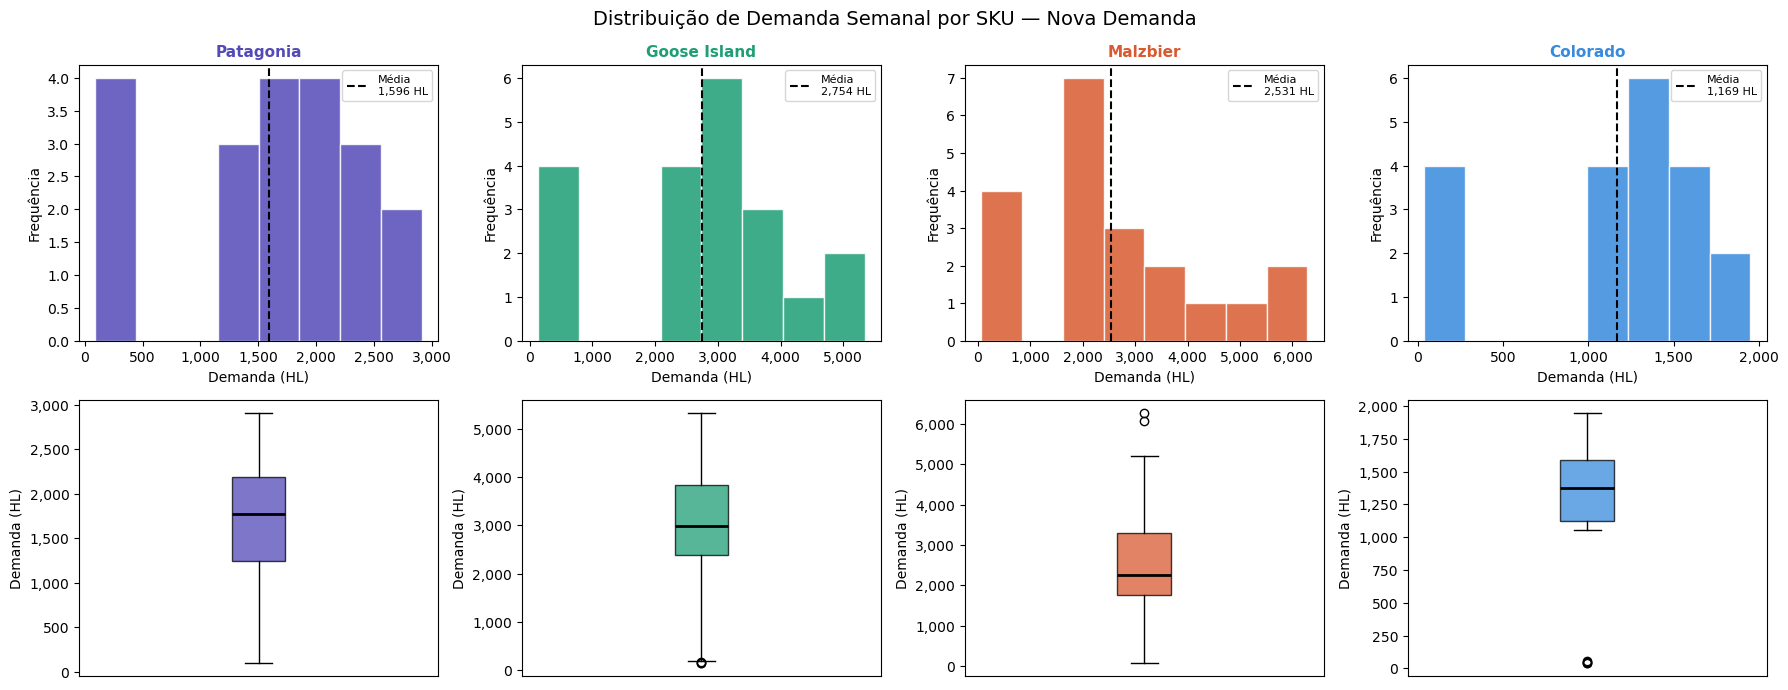

In [47]:
import matplotlib.ticker as mticker
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Distribuição de Demanda Semanal por SKU — Nova Demanda', fontsize=14)

for i, sku in enumerate(SKUS):
    dados = df_new[df_new.sku==sku]['dem'].dropna()
    cor   = SKU_CORES[sku]
    # histograma
    ax = axes[0,i]
    ax.hist(dados, bins=8, color=cor, alpha=0.85, edgecolor='white')
    ax.axvline(dados.mean(), color='black', lw=1.5, linestyle='--',
               label=f'Média\n{dados.mean():,.0f} HL')
    ax.set_title(sku, fontsize=11, color=cor, fontweight='bold')
    ax.set_xlabel('Demanda (HL)'); ax.set_ylabel('Frequência'); ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
    # boxplot
    ax = axes[1,i]
    bp = ax.boxplot(dados, patch_artist=True, vert=True,
                    medianprops=dict(color='black',lw=2))
    bp['boxes'][0].set_facecolor(cor); bp['boxes'][0].set_alpha(0.75)
    ax.set_ylabel('Demanda (HL)'); ax.set_xticks([])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

plt.tight_layout(); plt.show()


### 1.3 Distribuição de DOI por SKU e cenário


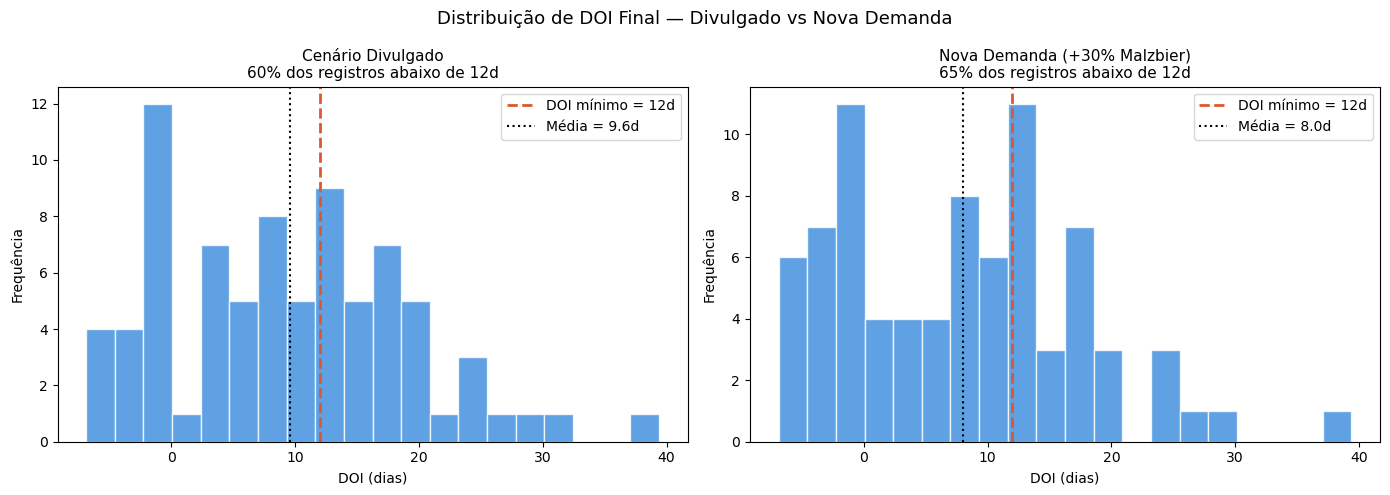

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de DOI Final — Divulgado vs Nova Demanda', fontsize=13)

for ax, (df, titulo) in zip(axes,
        [(df_div,'Cenário Divulgado'),(df_new,'Nova Demanda (+30% Malzbier)')]):
    doi = df['suf_f'].dropna()
    ax.hist(doi, bins=20, color='#378ADD', alpha=0.8, edgecolor='white')
    ax.axvline(DOI_MIN, color='#D85A30', lw=2, linestyle='--',
               label=f'DOI mínimo = {DOI_MIN}d')
    ax.axvline(doi.mean(), color='black', lw=1.5, linestyle=':',
               label=f'Média = {doi.mean():.1f}d')
    pct = (doi < DOI_MIN).mean()*100
    ax.set_title(f'{titulo}\n{pct:.0f}% dos registros abaixo de {DOI_MIN}d', fontsize=11)
    ax.set_xlabel('DOI (dias)'); ax.set_ylabel('Frequência'); ax.legend()

plt.tight_layout(); plt.show()


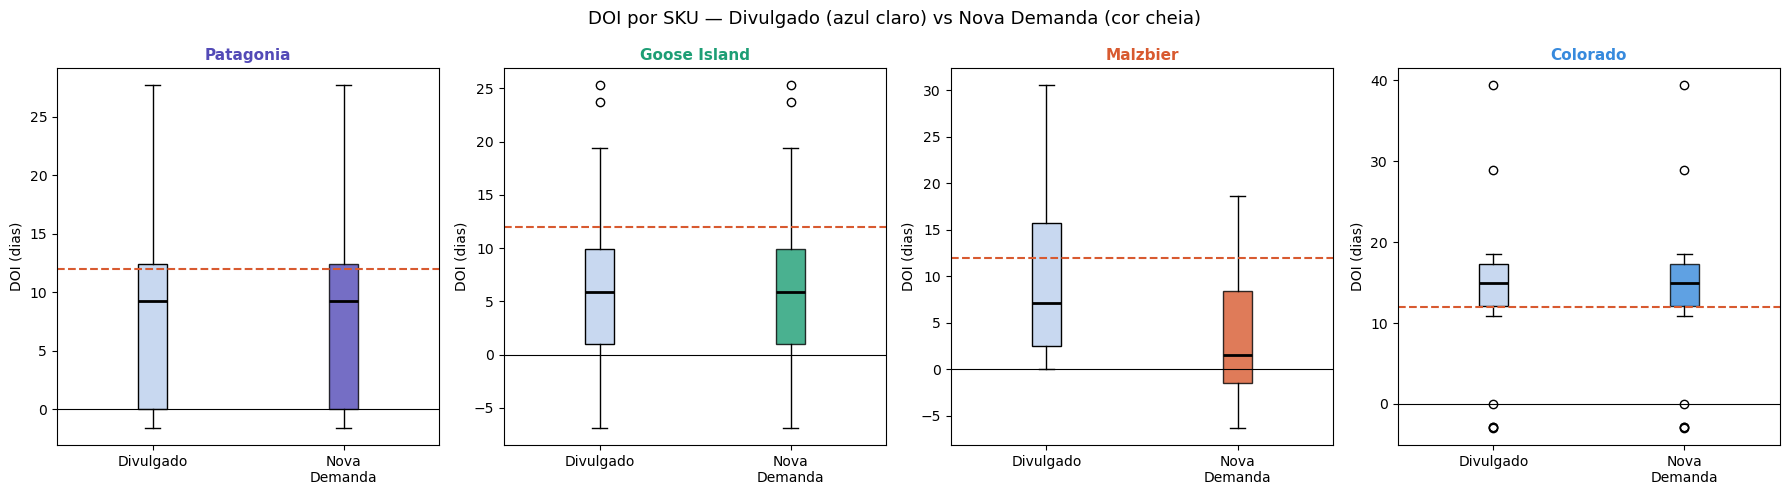

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('DOI por SKU — Divulgado (azul claro) vs Nova Demanda (cor cheia)', fontsize=13)
import matplotlib.colors as mcolors

for i, sku in enumerate(SKUS):
    ax  = axes[i]
    d1  = df_div[df_div.sku==sku]['suf_f'].dropna()
    d2  = df_new[df_new.sku==sku]['suf_f'].dropna()
    cor = SKU_CORES[sku]
    bp  = ax.boxplot([d1,d2], patch_artist=True, medianprops=dict(color='black',lw=2),
                     labels=['Divulgado','Nova\nDemanda'])
    bp['boxes'][0].set_facecolor('#C8D8F0')
    bp['boxes'][1].set_facecolor(cor); bp['boxes'][1].set_alpha(0.80)
    ax.axhline(DOI_MIN, color='#D85A30', lw=1.5, linestyle='--')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(sku, fontsize=11, color=cor, fontweight='bold')
    ax.set_ylabel('DOI (dias)')

plt.tight_layout(); plt.show()


### 1.4 Produção PCP — utilização de capacidade


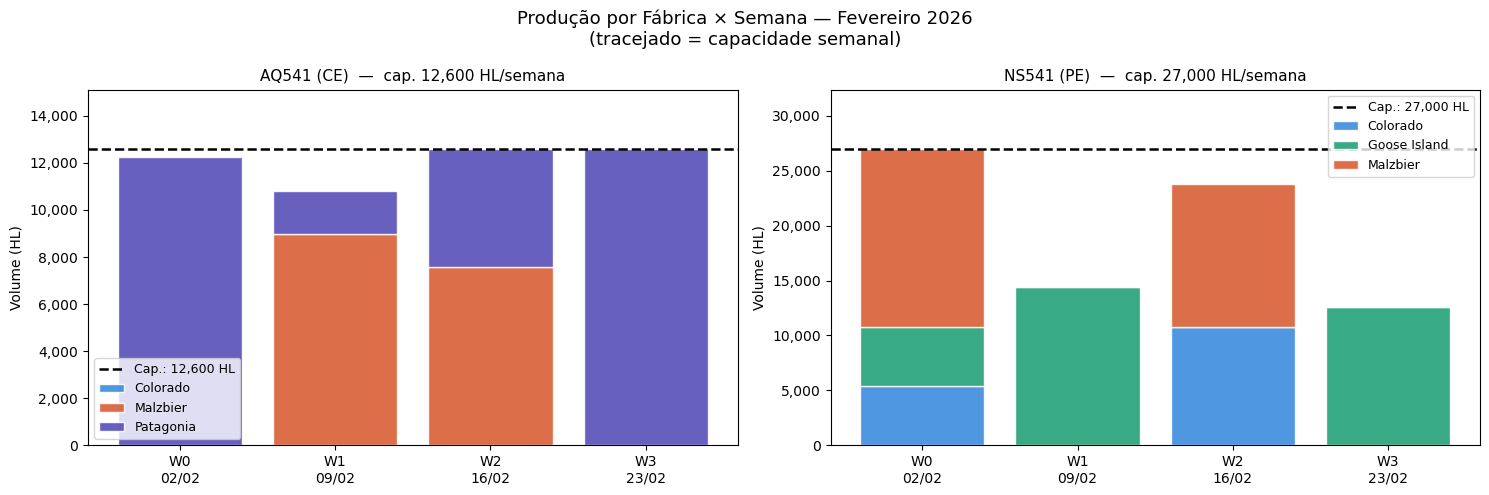


Utilização de capacidade por fábrica e semana (%):


semana,W0,W1,W2,W3
fabrica,,,,
AQ541 (CE),97.10,85.70,100.00,100.00
NS541 (PE),100.00,53.30,88.00,46.70


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Produção por Fábrica × Semana — Fevereiro 2026\n(tracejado = capacidade semanal)', fontsize=13)

for ax, fab in zip(axes, ['AQ541 (CE)','NS541 (PE)']):
    sub = df_pcp[df_pcp.fabrica==fab]
    cap = sub['cap_semanal'].iloc[0]
    pivot = (sub.groupby(['semana','sku'])['wsnp'].sum()
               .unstack(fill_value=0).reindex(SEMANAS))
    x = np.arange(len(SEMANAS)); bottom = np.zeros(len(SEMANAS))
    for sku_col in pivot.columns:
        ax.bar(x, pivot[sku_col].values, bottom=bottom,
               color=SKU_CORES.get(sku_col,'#888'), label=sku_col, alpha=0.88, edgecolor='white')
        bottom += pivot[sku_col].values
    ax.axhline(cap, color='black', lw=1.8, linestyle='--', label=f'Cap.: {cap:,.0f} HL')
    ax.set_title(f'{fab}  —  cap. {cap:,.0f} HL/semana', fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels([f'{s}\n{DATAS[s]}' for s in SEMANAS])
    ax.set_ylabel('Volume (HL)'); ax.set_ylim(0, cap*1.2); ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

plt.tight_layout(); plt.show()

print('\nUtilização de capacidade por fábrica e semana (%):')
util = []
for fab in ['AQ541 (CE)','NS541 (PE)']:
    sub = df_pcp[df_pcp.fabrica==fab]; cap = sub['cap_semanal'].iloc[0]
    for s in SEMANAS:
        prod = sub[sub.semana==s]['wsnp'].sum()
        util.append(dict(fabrica=fab, semana=s, prod_hl=prod, cap=cap, util_pct=round(prod/cap*100,1)))
display(pd.DataFrame(util).pivot_table(index='fabrica', columns='semana', values='util_pct').round(1))


### 1.5 Estrutura de custos — MACO, margem e frete


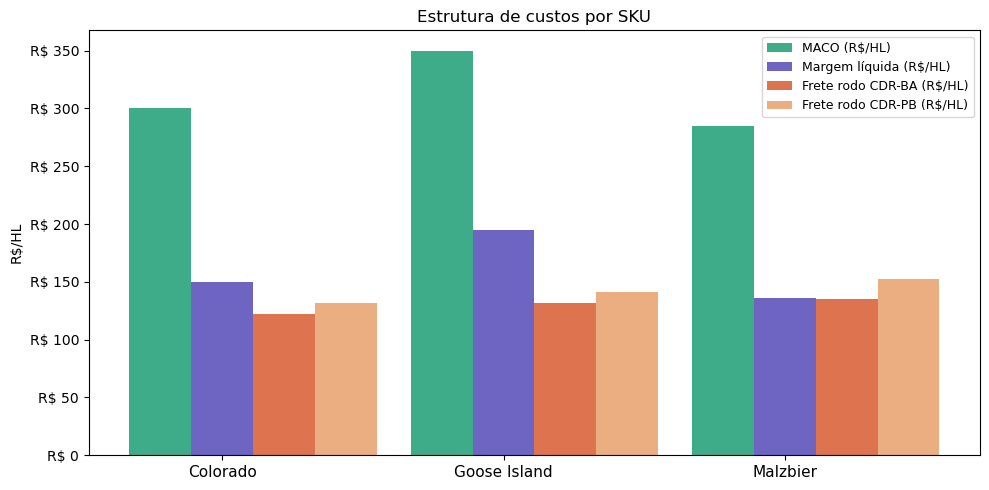

Tabela MACO / Margem:


,sku,maco,custo_prod,margem_liq
0,Colorado,300,150,150
1,Goose Island,350,155,195
2,Malzbier,285,149,136



Fretes por rota:


,sku,cdr,frete_cabo,frete_rodo
0,Colorado,BA,76.59,122.55
1,Colorado,PB,82.08,131.33
2,Goose Island,BA,82.40,131.83
3,Goose Island,PB,88.30,141.28
4,Malzbier,BA,84.58,135.33
5,Malzbier,PB,95.33,152.53


In [51]:
skus_ct = df_econ['sku'].tolist()
x = np.arange(len(skus_ct)); w = 0.22

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x-w,  df_econ['maco'],       width=w, label='MACO (R$/HL)',          color='#1D9E75', alpha=0.85)
ax.bar(x,    df_econ['margem_liq'], width=w, label='Margem líquida (R$/HL)', color='#534AB7', alpha=0.85)
for j, cdr in enumerate(['BA','PB']):
    sub_f = df_frete[df_frete.cdr==cdr]
    vals  = [sub_f[sub_f.sku==s]['frete_rodo'].values[0] if s in sub_f.sku.values else 0 for s in skus_ct]
    ax.bar(x+w*(j+1), vals, width=w, label=f'Frete rodo CDR-{cdr} (R$/HL)',
           color=['#D85A30','#E8A06B'][j], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(skus_ct, fontsize=11)
ax.set_ylabel('R$/HL'); ax.set_title('Estrutura de custos por SKU', fontsize=12); ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R$ {v:,.0f}'))
plt.tight_layout(); plt.show()

print('Tabela MACO / Margem:')
display(df_econ)
print('\nFretes por rota:')
display(df_frete.sort_values(['sku','cdr']))


---
## 2. Análise Bivariada


### 2.1 Impacto da nova demanda por SKU — Divulgado vs Nova Demanda


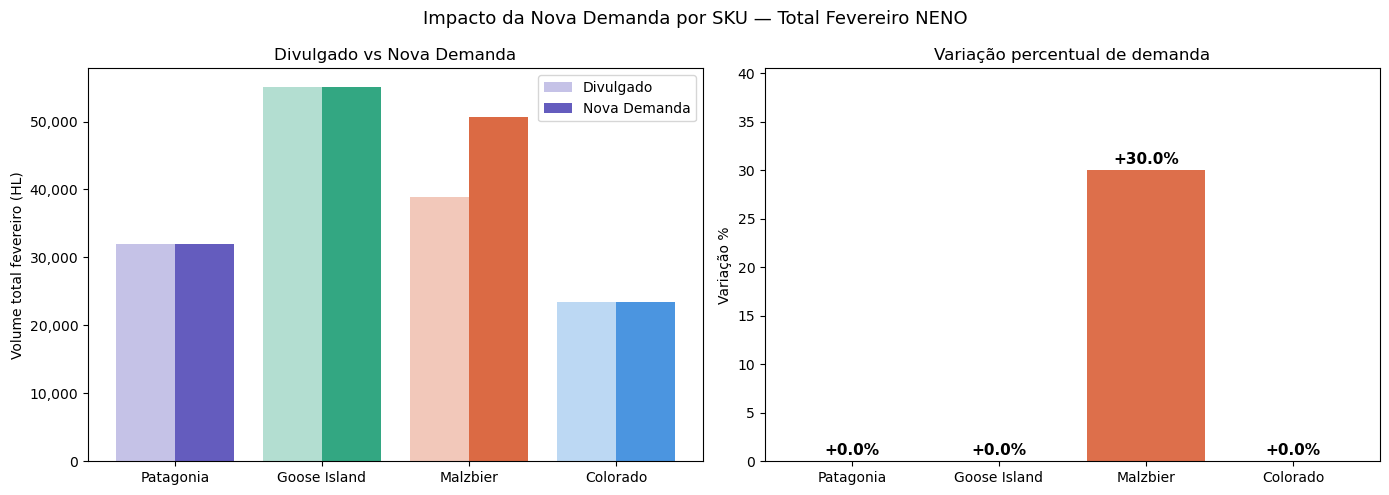

,dem_div,dem_new,delta_hl,delta_pct
sku,,,,
Patagonia,"31,927.20","31,927.20",0.00,0.00
Goose Island,"55,070.90","55,070.90",0.00,0.00
Malzbier,"38,934.00","50,614.20","11,680.20",30.00
Colorado,"23,385.30","23,385.30",0.00,0.00


In [52]:
dem_div = df_div.groupby('sku')['dem'].sum().rename('dem_div')
dem_new = df_new.groupby('sku')['dem'].sum().rename('dem_new')
delta   = pd.concat([dem_div, dem_new], axis=1).reindex(SKUS)
delta['delta_hl']  = delta['dem_new'] - delta['dem_div']
delta['delta_pct'] = (delta['delta_hl'] / delta['dem_div'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Impacto da Nova Demanda por SKU — Total Fevereiro NENO', fontsize=13)
x = np.arange(len(SKUS)); cores = [SKU_CORES[s] for s in SKUS]

ax = axes[0]
ax.bar(x-0.2, delta['dem_div'], width=0.4, color=[c+'55' for c in cores], label='Divulgado', edgecolor='none')
ax.bar(x+0.2, delta['dem_new'], width=0.4, color=cores, alpha=0.9, label='Nova Demanda')
ax.set_xticks(x); ax.set_xticklabels(SKUS, fontsize=10)
ax.set_ylabel('Volume total fevereiro (HL)'); ax.set_title('Divulgado vs Nova Demanda'); ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

ax = axes[1]
bars = ax.bar(x, delta['delta_pct'], color=cores, alpha=0.87)
for bar, pct in zip(bars, delta['delta_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'+{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(SKUS, fontsize=10)
ax.set_ylabel('Variação %'); ax.set_title('Variação percentual de demanda')
ax.set_ylim(0, delta['delta_pct'].max()*1.35)

plt.tight_layout(); plt.show()
display(delta.round(1))


### 2.2 Mapa de calor — DOI por GEO × Semana


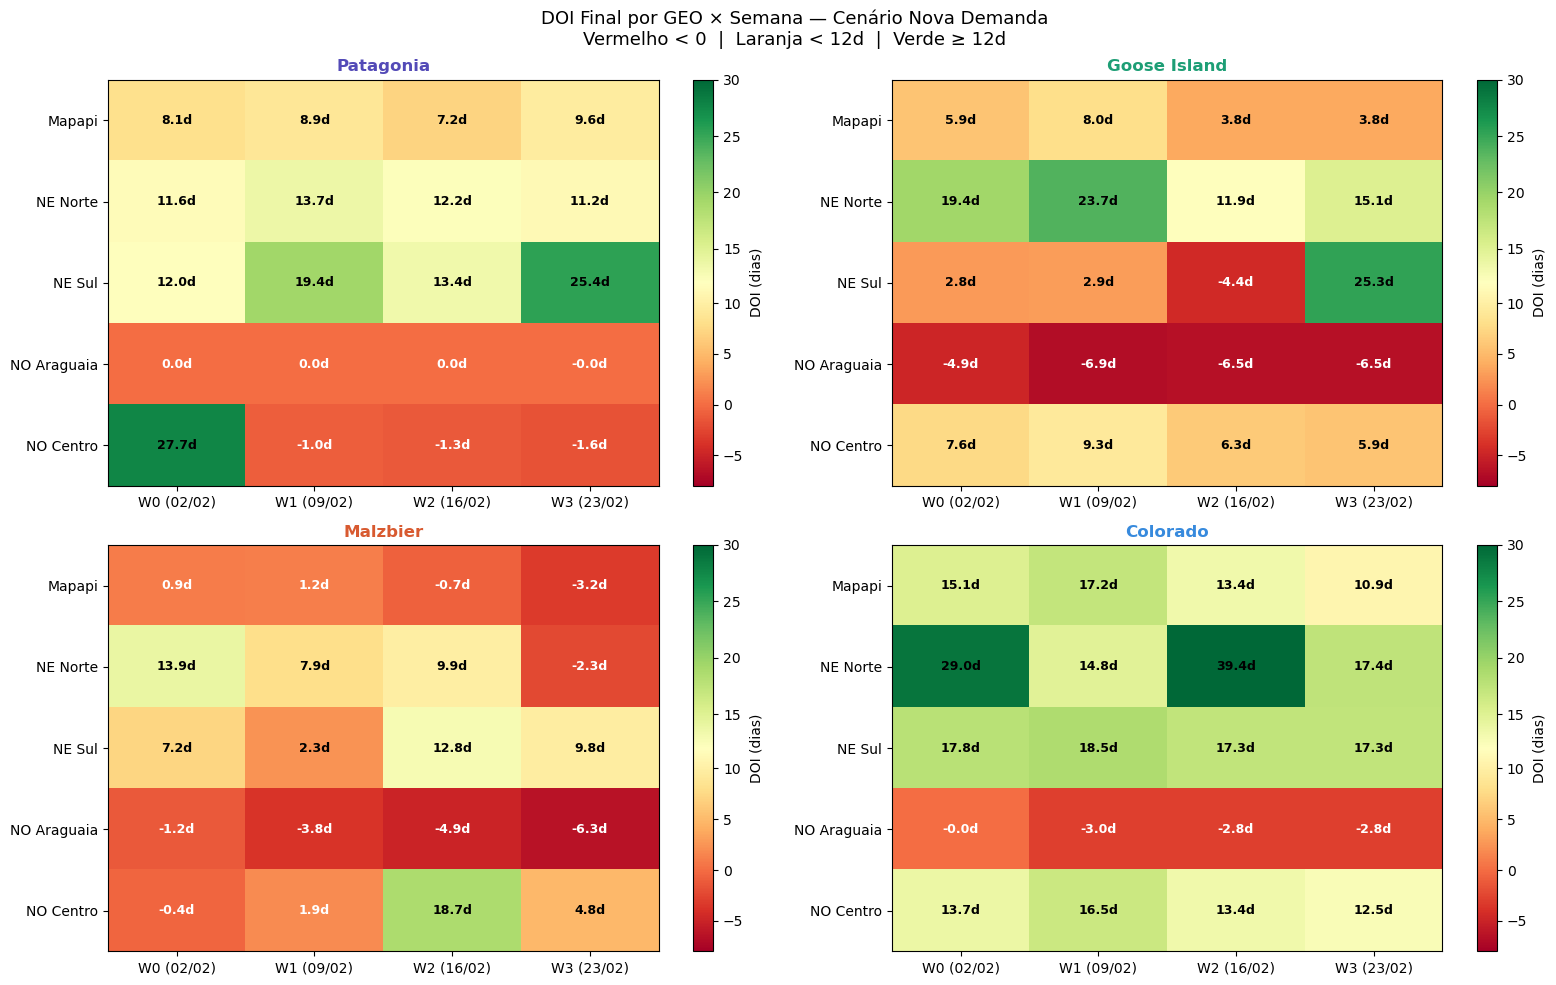

In [53]:
import matplotlib.colors as mcolors
fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.suptitle('DOI Final por GEO × Semana — Cenário Nova Demanda\n'
             'Vermelho < 0  |  Laranja < 12d  |  Verde ≥ 12d', fontsize=13)
cmap = plt.cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=-8, vcenter=DOI_MIN, vmax=30)

for ax, sku in zip(axes.flat, SKUS):
    pivot = (df_new[df_new.sku==sku]
             .pivot_table(index='geo', columns='semana', values='suf_f')
             .reindex(GEOS_NENO).reindex(SEMANAS, axis=1))
    im = ax.imshow(pivot.values, cmap=cmap, norm=norm, aspect='auto')
    ax.set_xticks(range(4)); ax.set_xticklabels([f'{s} ({DATAS[s]})' for s in SEMANAS])
    ax.set_yticks(range(len(GEOS_NENO))); ax.set_yticklabels(GEOS_NENO)
    ax.set_title(sku, fontsize=12, color=SKU_CORES[sku], fontweight='bold')
    for i in range(len(GEOS_NENO)):
        for j in range(4):
            v = pivot.values[i,j]
            if pd.notna(v):
                ax.text(j, i, f'{v:.1f}d', ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white' if v < 2 else 'black')
    plt.colorbar(im, ax=ax, label='DOI (dias)')

plt.tight_layout(); plt.show()


### 2.3 Produção NENO vs Demanda NENO — gap de abastecimento


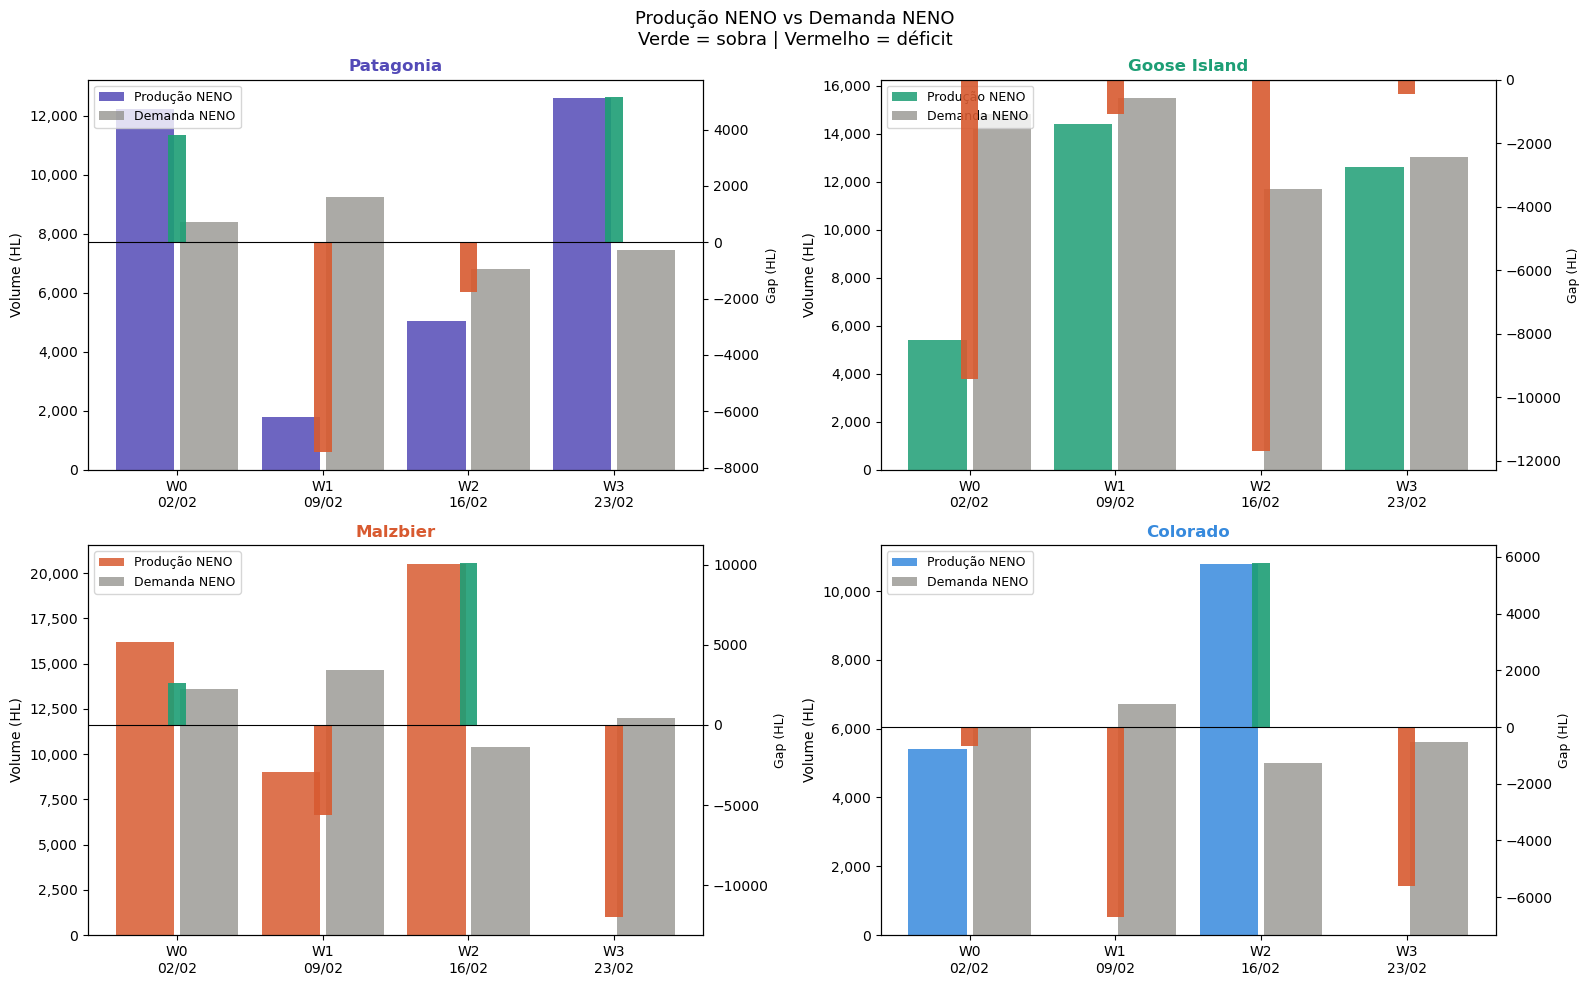

Gap semanal (Produção NENO − Demanda NENO):


semana,W0,W1,W2,W3
sku,,,,
Patagonia,"3,821.00","-7,449.00","-1,763.00","5,143.00"
Goose Island,"-9,442.00","-1,079.00","-11,701.00",-449.00
Malzbier,"2,617.00","-5,626.00","10,112.00","-11,998.00"
Colorado,-652.00,"-6,713.00","5,796.00","-5,616.00"


In [54]:
prod_total = (df_pcp.groupby(['sku','semana'])['wsnp'].sum()
              .reset_index().rename(columns={'wsnp':'prod_neno'}))
dem_total  = (df_new.groupby(['sku','semana'])['dem'].sum()
              .reset_index().rename(columns={'dem':'dem_neno'}))

for _df in [prod_total, dem_total]:
    _df['sku']    = _df['sku'].astype(str)
    _df['semana'] = _df['semana'].astype(str)

balance    = prod_total.merge(dem_total, on=['sku','semana'], how='outer').fillna(0)
balance['gap'] = balance['prod_neno'] - balance['dem_neno']

fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.suptitle('Produção NENO vs Demanda NENO\nVerde = sobra | Vermelho = déficit', fontsize=13)

for ax, sku in zip(axes.flat, SKUS):
    sub = balance[balance.sku==sku].sort_values('semana')
    x   = np.arange(len(sub)); cor = SKU_CORES[sku]
    ax.bar(x-0.22, sub['prod_neno'], width=0.4, color=cor, alpha=0.85, label='Produção NENO')
    ax.bar(x+0.22, sub['dem_neno'],  width=0.4, color='#888780', alpha=0.70, label='Demanda NENO')
    ax2 = ax.twinx()
    gap_cores = ['#1D9E75' if g>=0 else '#D85A30' for g in sub['gap']]
    ax2.bar(x, sub['gap'], width=0.12, color=gap_cores, alpha=0.9)
    ax2.axhline(0, color='black', lw=0.8); ax2.set_ylabel('Gap (HL)', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels([f'{s}\n{DATAS[s]}' for s in sub['semana']])
    ax.set_title(sku, fontsize=12, color=cor, fontweight='bold')
    ax.set_ylabel('Volume (HL)'); ax.legend(loc='upper left', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

plt.tight_layout(); plt.show()

print('Gap semanal (Produção NENO − Demanda NENO):')
display(balance.pivot_table(index='sku',columns='semana',values='gap').reindex(SKUS).round(0))


### 2.4 Evolução semanal — Demanda e DOI por SKU × GEO


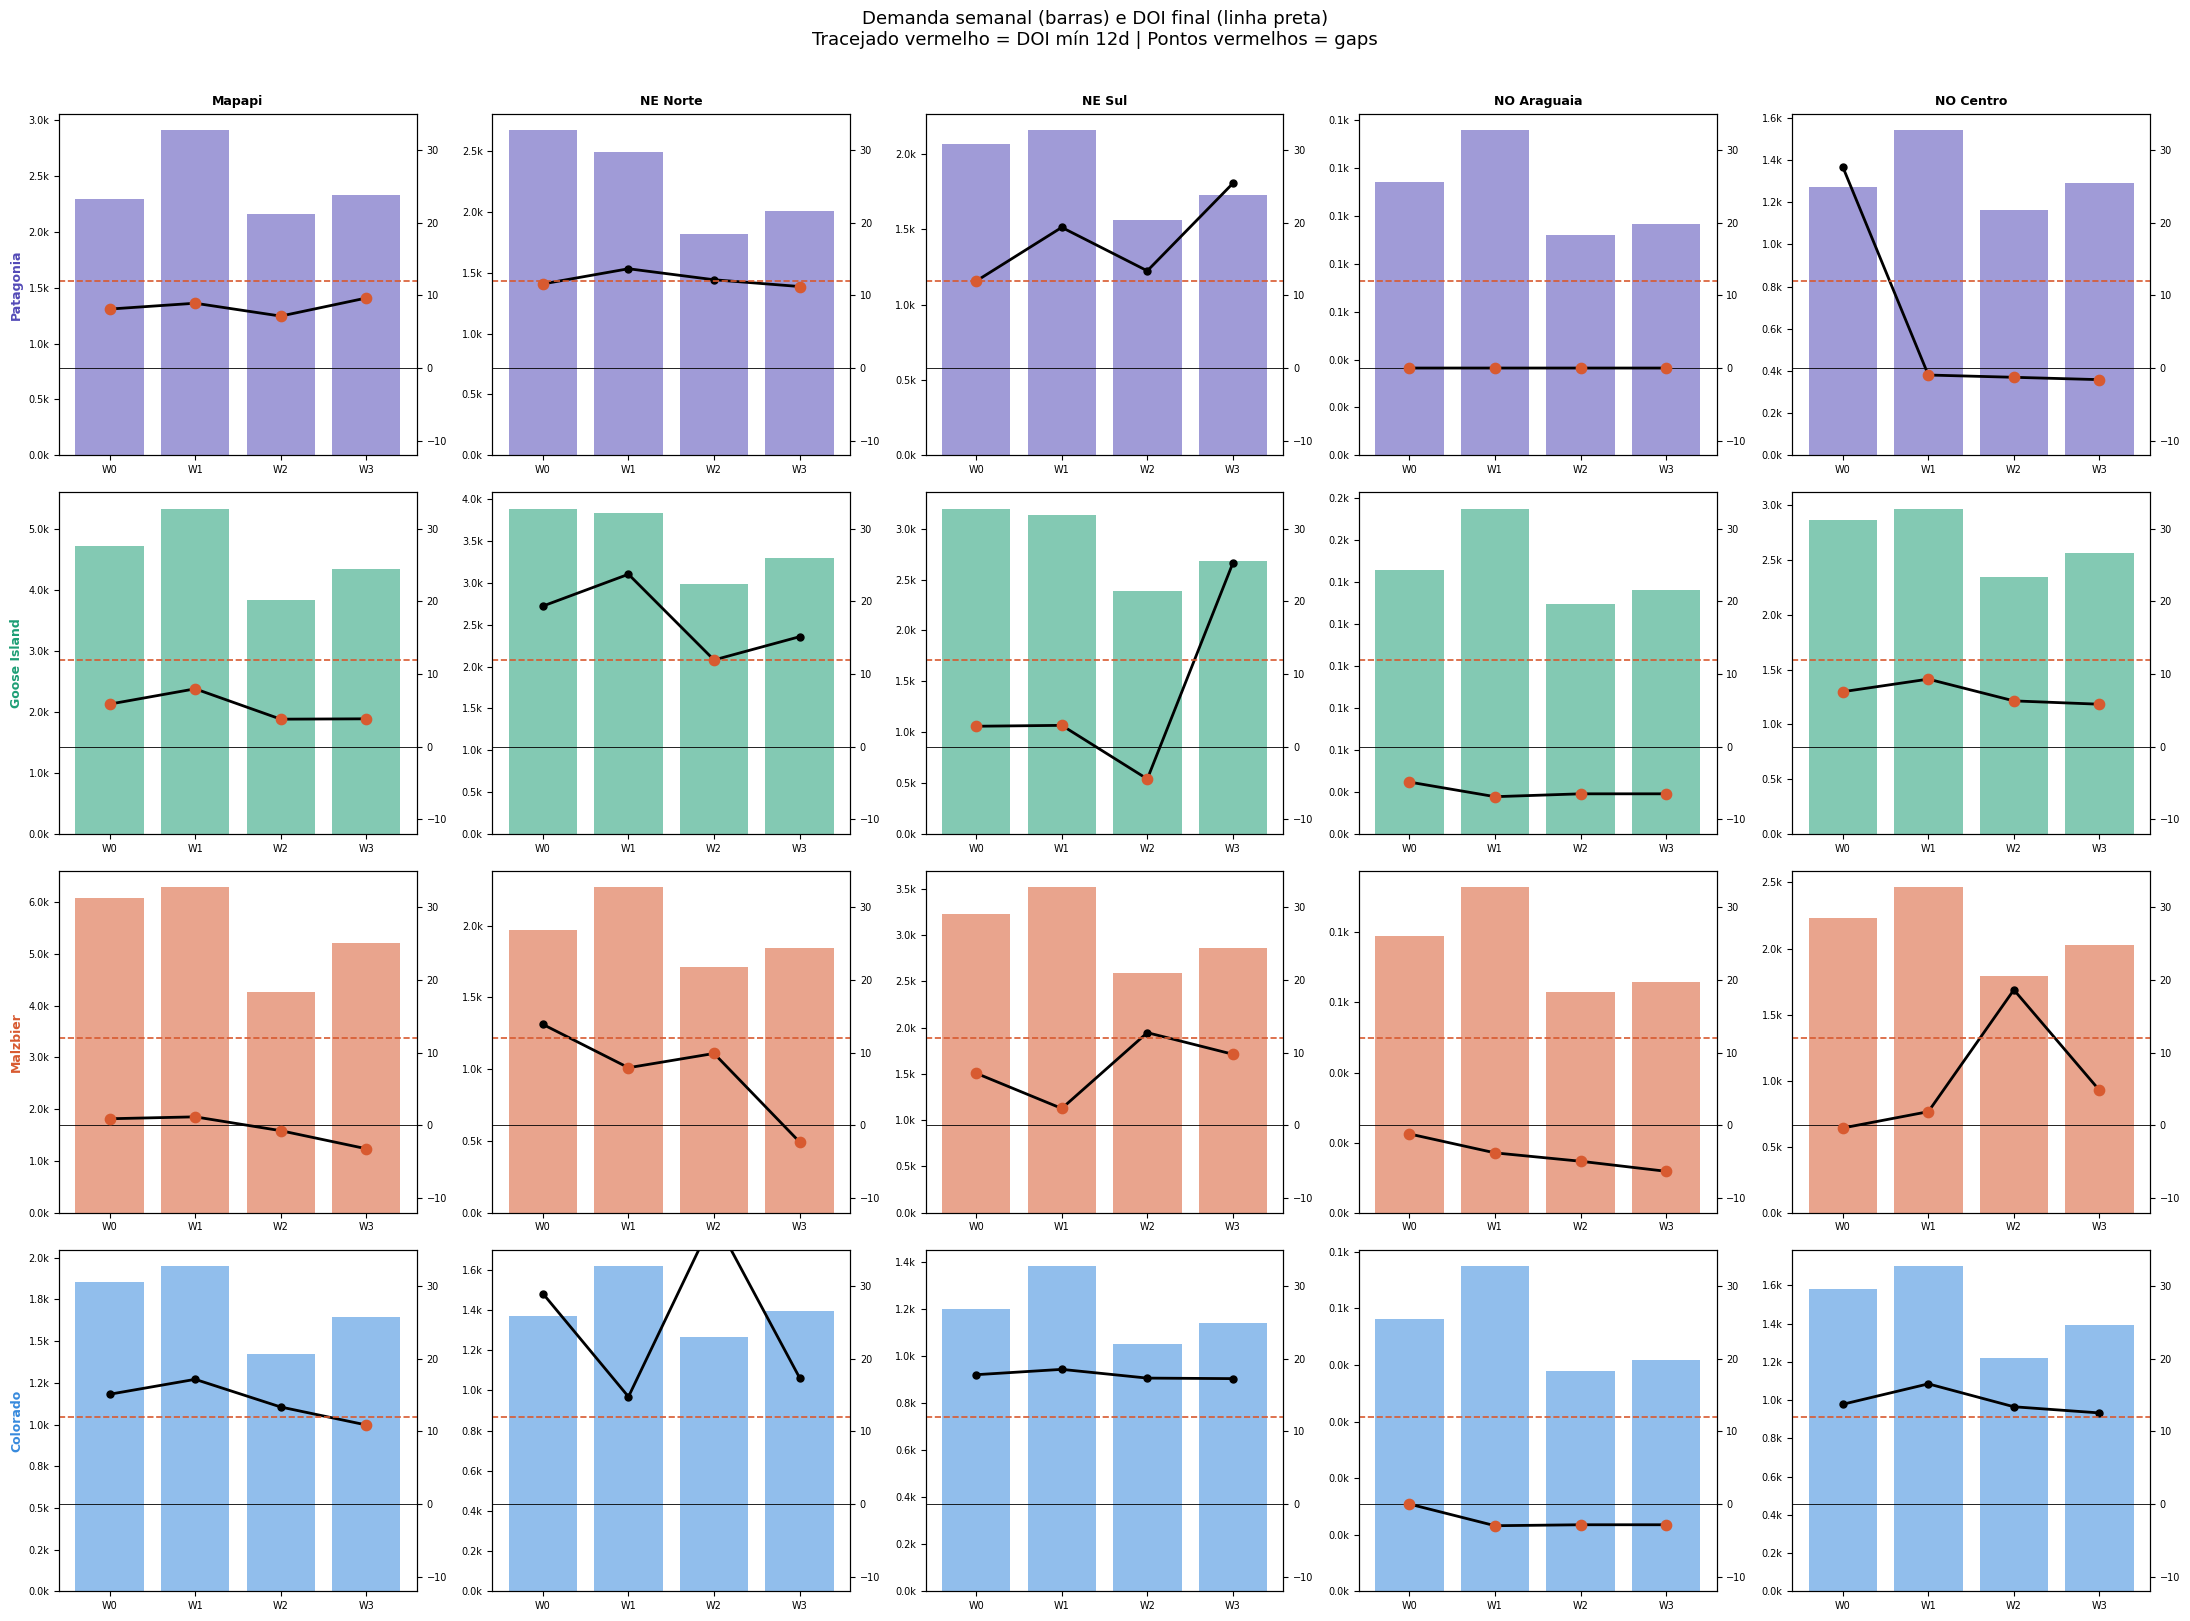

In [55]:
fig, axes = plt.subplots(4, 5, figsize=(22,16))
fig.suptitle('Demanda semanal (barras) e DOI final (linha preta)\n'
             'Tracejado vermelho = DOI mín 12d | Pontos vermelhos = gaps', fontsize=13, y=1.01)

for ri, sku in enumerate(SKUS):
    for ci, geo in enumerate(GEOS_NENO):
        ax  = axes[ri,ci]
        sub = df_new[(df_new.sku==sku)&(df_new.geo==geo)].sort_values('semana')
        x   = np.arange(len(sub)); cor = SKU_CORES[sku]
        ax.bar(x, sub['dem'].values, color=cor, alpha=0.55)
        ax2 = ax.twinx()
        doi_vals = sub['suf_f'].values
        ax2.plot(x, doi_vals, color='black', lw=2, marker='o', ms=5)
        ax2.axhline(DOI_MIN, color='#D85A30', lw=1.2, linestyle='--')
        ax2.axhline(0, color='black', lw=0.6); ax2.set_ylim(-12,35)
        ax2.tick_params(labelsize=7)
        for xi, doi in enumerate(doi_vals):
            if doi is not None and doi < DOI_MIN:
                ax2.scatter(xi, doi, color='#D85A30', s=55, zorder=5)
        ax.set_xticks(x); ax.set_xticklabels(list(sub['semana']), fontsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e3:.1f}k'))
        if ci==0: ax.set_ylabel(sku, fontsize=9, color=cor, fontweight='bold')
        if ri==0: ax.set_title(geo, fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()


### 2.5 Viabilidade econômica do frete rodoviário


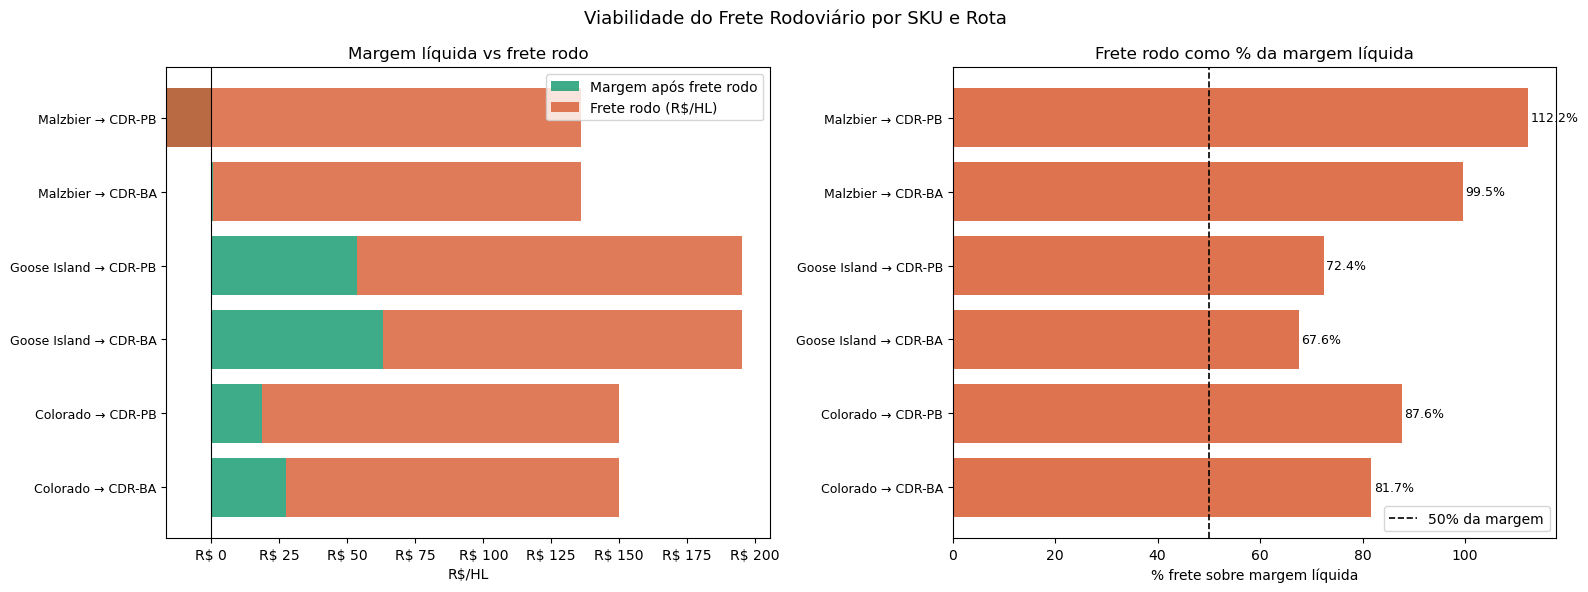

,rota,maco,custo_prod,margem_liq,frete_cabo,frete_rodo,margem_pos_rodo,pct_frete_margem
0,Colorado → CDR-BA,300,150,150,76.59,122.55,27.45,81.70
1,Colorado → CDR-PB,300,150,150,82.08,131.33,18.67,87.60
2,Goose Island → CDR-BA,350,155,195,82.40,131.83,63.17,67.60
3,Goose Island → CDR-PB,350,155,195,88.30,141.28,53.72,72.40
4,Malzbier → CDR-BA,285,149,136,84.58,135.33,0.67,99.50
5,Malzbier → CDR-PB,285,149,136,95.33,152.53,-16.53,112.20


In [56]:
df_via = df_frete.merge(df_econ, on='sku')
df_via['margem_pos_rodo']  = df_via['margem_liq'] - df_via['frete_rodo']
df_via['pct_frete_margem'] = (df_via['frete_rodo'] / df_via['margem_liq'] * 100).round(1)
df_via['rota'] = df_via['sku'] + ' → CDR-' + df_via['cdr']

fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle('Viabilidade do Frete Rodoviário por SKU e Rota', fontsize=13)
y = np.arange(len(df_via)); rotulos = df_via['rota'].tolist()

ax = axes[0]
ax.barh(y, df_via['margem_pos_rodo'], color='#1D9E75', alpha=0.85, label='Margem após frete rodo')
ax.barh(y, df_via['frete_rodo'], left=df_via['margem_pos_rodo'],
        color='#D85A30', alpha=0.8, label='Frete rodo (R$/HL)')
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(rotulos, fontsize=9)
ax.set_xlabel('R$/HL'); ax.set_title('Margem líquida vs frete rodo'); ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R$ {v:,.0f}'))

ax = axes[1]
bar_cores = ['#D85A30' if p>50 else '#1D9E75' for p in df_via['pct_frete_margem']]
bars = ax.barh(y, df_via['pct_frete_margem'], color=bar_cores, alpha=0.85)
for bar, pct in zip(bars, df_via['pct_frete_margem']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.axvline(50, color='black', lw=1.2, linestyle='--', label='50% da margem')
ax.set_yticks(y); ax.set_yticklabels(rotulos, fontsize=9)
ax.set_xlabel('% frete sobre margem líquida'); ax.legend()
ax.set_title('Frete rodo como % da margem líquida')

plt.tight_layout(); plt.show()
display(df_via[['rota','maco','custo_prod','margem_liq',
                'frete_cabo','frete_rodo','margem_pos_rodo','pct_frete_margem']].round(2))


### 2.6 Transferência Interna × DOI — eficiência da malha


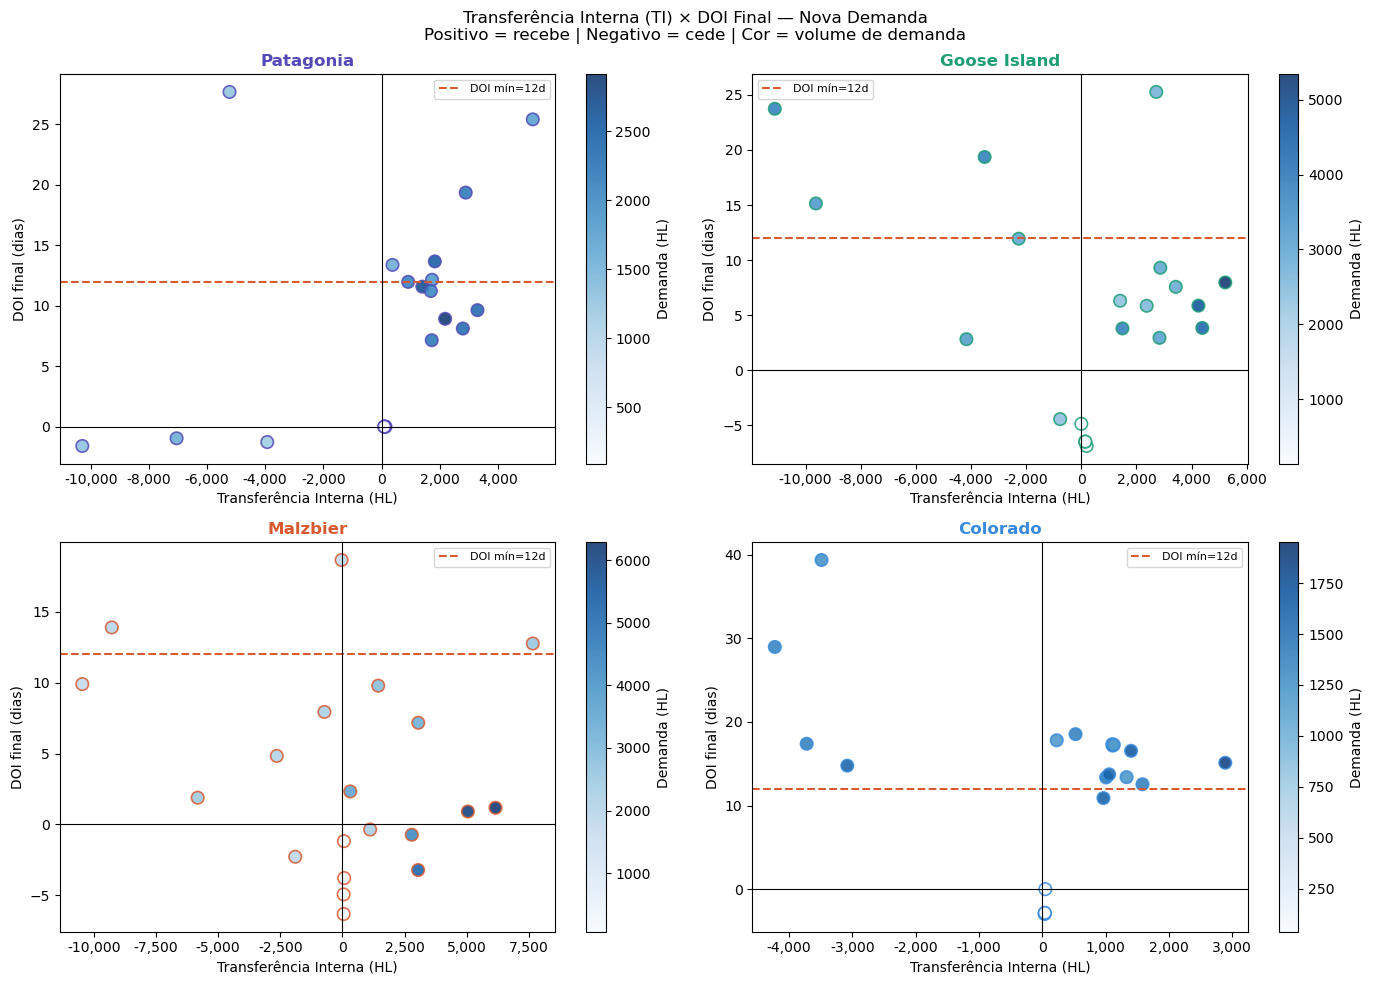

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Transferência Interna (TI) × DOI Final — Nova Demanda\n'
             'Positivo = recebe | Negativo = cede | Cor = volume de demanda', fontsize=12)

for ax, sku in zip(axes.flat, SKUS):
    sub = df_new[df_new.sku==sku]
    sc  = ax.scatter(sub['ti'], sub['suf_f'], c=sub['dem'], cmap='Blues',
                     s=80, alpha=0.85, edgecolors=SKU_CORES[sku], linewidths=1.2)
    ax.axhline(DOI_MIN, color='#D85A30', lw=1.5, linestyle='--', label=f'DOI mín={DOI_MIN}d')
    ax.axhline(0, color='black', lw=0.8); ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Transferência Interna (HL)'); ax.set_ylabel('DOI final (dias)')
    ax.set_title(sku, fontsize=12, color=SKU_CORES[sku], fontweight='bold')
    ax.legend(fontsize=8); plt.colorbar(sc, ax=ax, label='Demanda (HL)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

plt.tight_layout(); plt.show()


### 2.7 Tabela e gráfico de déficits para DOI = 12 dias


Combinações SKU × GEO × Semana com DOI < 12d: 52
Volume adicional necessário para fechar DOI = 12d: 110,315 HL


,sku,geo,semana,dem,ef,suf_f,ef_meta,deficit_hl
0,Colorado,Mapapi,W3,"1,644.00","2,983.60",10.90,"2,818.20",0.00
1,Colorado,NO Araguaia,W0,48.10,-0.00,-0.00,82.50,82.00
2,Colorado,NO Araguaia,W1,57.50,-19.30,-3.00,98.50,118.00
3,Colorado,NO Araguaia,W2,39.00,-19.30,-2.80,66.80,86.00
4,Colorado,NO Araguaia,W3,40.80,-19.30,-2.80,69.90,89.00
5,Goose Island,Mapapi,W0,"4,732.50","5,219.10",5.90,"8,112.90","2,894.00"
6,Goose Island,Mapapi,W1,"5,340.60","5,099.10",8.00,"9,155.30","4,056.00"
7,Goose Island,Mapapi,W2,"3,839.20","2,751.70",3.80,"6,581.40","3,830.00"
8,Goose Island,Mapapi,W3,"4,352.90","2,785.60",3.80,"7,462.20","4,677.00"
9,Goose Island,NE Norte,W2,"2,989.80","6,570.10",11.90,"5,125.30",0.00


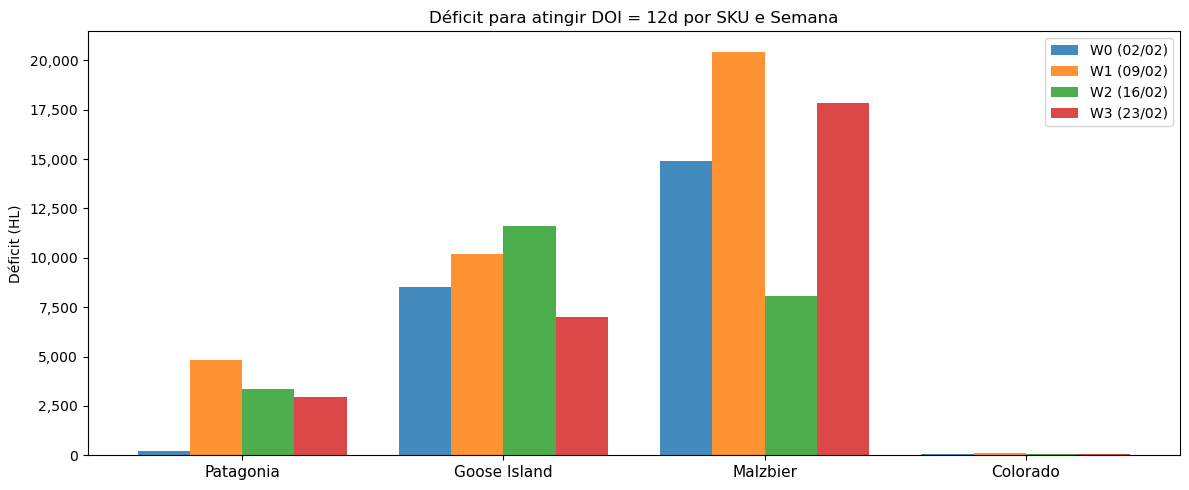

In [58]:
gaps = df_new[df_new['suf_f'] < DOI_MIN][['sku','geo','semana','dem','ef','suf_f']].copy()
gaps['ef_meta']    = (gaps['dem']/7) * DOI_MIN
gaps['deficit_hl'] = (gaps['ef_meta'] - gaps['ef']).clip(lower=0).round(0)
gaps = gaps.sort_values(['sku','geo','semana']).reset_index(drop=True)

print(f'Combinações SKU × GEO × Semana com DOI < {DOI_MIN}d: {len(gaps)}')
print(f'Volume adicional necessário para fechar DOI = {DOI_MIN}d: {gaps["deficit_hl"].sum():,.0f} HL')
display(gaps.round(1))

pivot_gap = (gaps.groupby(['sku','semana'])['deficit_hl']
             .sum().unstack(fill_value=0).reindex(SKUS))

fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(SKUS)); w = 0.20
for i, sem in enumerate(SEMANAS):
    vals = [pivot_gap.loc[s,sem] if (s in pivot_gap.index and sem in pivot_gap.columns) else 0
            for s in SKUS]
    ax.bar(x+(i-1.5)*w, vals, width=w, label=f'{sem} ({DATAS[sem]})', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(SKUS, fontsize=11)
ax.set_ylabel('Déficit (HL)')
ax.set_title(f'Déficit para atingir DOI = {DOI_MIN}d por SKU e Semana', fontsize=12)
ax.legend(); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
plt.tight_layout(); plt.show()


---
## (Bivariado Extensão)3. DOI × Semana e Comparativos Divulgado vs Nova Demanda

Gráficos nesta seção:
- **3.1** Heatmap unificado SKU × Semana (ambos cenários lado a lado)
- **3.2** Linha temporal DOI — todos SKUs, sólido=Nova vs tracejado=Div
- **3.3** Demanda total NENO — barras + Δ heatmap
- **3.4** Estoque Final — evolução + Δ heatmap
- **3.5** Malzbier: Div → Nova → Δ DOI por GEO
- **3.6** Ranking de criticidade por SKU × GEO


In [59]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np

# Pivots reutilizados em todos os gráficos
doi_div = (df_div.groupby(['sku','semana'])['suf_f']
           .mean().unstack().reindex(SKUS).reindex(SEMANAS, axis=1))
doi_new = (df_new.groupby(['sku','semana'])['suf_f']
           .mean().unstack().reindex(SKUS).reindex(SEMANAS, axis=1))

dem_div_w = (df_div.groupby(['sku','semana'])['dem']
             .sum().unstack().reindex(SKUS).reindex(SEMANAS, axis=1))
dem_new_w = (df_new.groupby(['sku','semana'])['dem']
             .sum().unstack().reindex(SKUS).reindex(SEMANAS, axis=1))
delta_dem = dem_new_w - dem_div_w

ef_div_w  = (df_div.groupby(['sku','semana'])['ef']
             .sum().unstack().reindex(SKUS).reindex(SEMANAS, axis=1))
ef_new_w  = (df_new.groupby(['sku','semana'])['ef']
             .sum().unstack().reindex(SKUS).reindex(SEMANAS, axis=1))
delta_ef  = ef_new_w - ef_div_w

doi_geo_div = (df_div.groupby(['sku','geo'])['suf_f']
               .mean().reset_index().rename(columns={'suf_f':'doi_div'}))
doi_geo_new = (df_new.groupby(['sku','geo'])['suf_f']
               .mean().reset_index().rename(columns={'suf_f':'doi_new'}))
rank = (doi_geo_div.merge(doi_geo_new, on=['sku','geo'])
        .assign(delta_doi=lambda x: x.doi_new - x.doi_div,
                critico_new=lambda x: x.doi_new < DOI_MIN)
        .sort_values('doi_new').reset_index(drop=True))

cmap_doi = plt.cm.RdYlGn
norm_doi  = mcolors.TwoSlopeNorm(vmin=-8, vcenter=12, vmax=30)
x4 = np.arange(4)
rotulos_w = [f'{s}\n({DATAS[s]})' for s in SEMANAS]

def _label_heatmap(ax, data, rows, cols, fs=11):
    """Escreve valores dentro de cada célula do imshow."""
    for i in range(len(rows)):
        for j in range(len(cols)):
            v = data[i, j]
            if np.isnan(v): continue
            cor_txt = 'white' if v < 1 else 'black'
            ax.text(j, i, f'{v:.1f}d', ha='center', va='center',
                    fontsize=fs, fontweight='bold', color=cor_txt)

def _style_ax(ax, rows, row_cores=None):
    """Aplica yticks coloridos, xticks no topo."""
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(rows, fontsize=10)
    if row_cores:
        for tick, sku in zip(ax.get_yticklabels(), rows):
            tick.set_color(row_cores[sku]); tick.set_fontweight('bold')
    ax.set_xticks(range(4))
    ax.set_xticklabels(rotulos_w, fontsize=9)
    ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')

print('Pivots OK')
print('doi_new:')
display(doi_new.round(2))


Pivots OK
doi_new:


semana,W0,W1,W2,W3
sku,,,,
Patagonia,11.87,8.20,6.28,8.93
Goose Island,6.15,7.41,2.22,8.72
Malzbier,4.09,1.91,7.13,0.56
Colorado,15.13,12.81,16.12,11.05


### 3.1 Heatmap unificado — DOI médio por SKU × Semana
> Uma linha por cerveja | Divulgado e Nova Demanda lado a lado


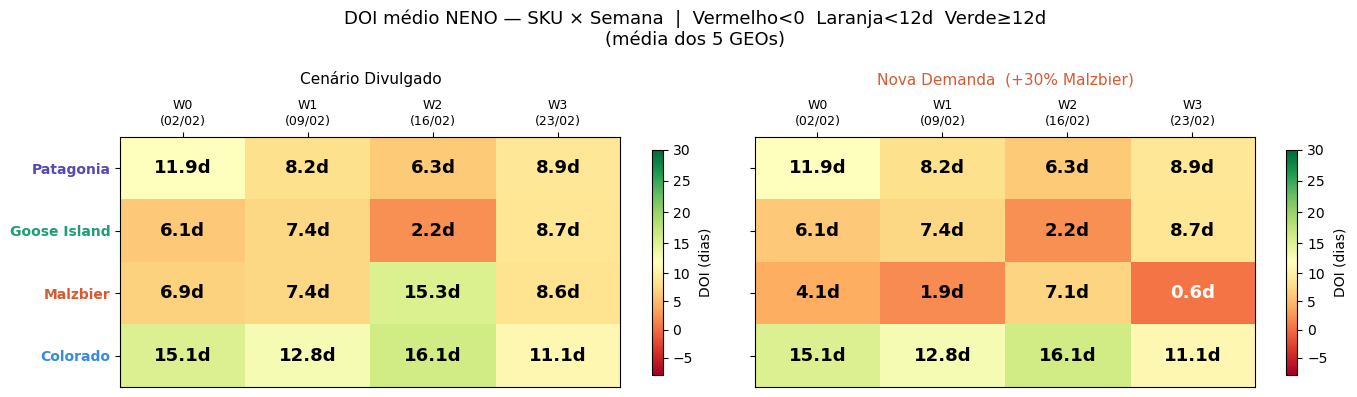

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle(
    'DOI médio NENO — SKU × Semana  |  Vermelho<0  Laranja<12d  Verde≥12d\n'
    '(média dos 5 GEOs)',
    fontsize=13
)

for ax, (data, titulo) in zip(axes, [
        (doi_div, 'Cenário Divulgado'),
        (doi_new, 'Nova Demanda  (+30% Malzbier)')
    ]):
    im = ax.imshow(data.values, cmap=cmap_doi, norm=norm_doi, aspect='auto')
    _label_heatmap(ax, data.values, SKUS, SEMANAS, fs=13)
    _style_ax(ax, SKUS, SKU_CORES)
    ax.set_title(titulo, fontsize=11, pad=38,
                 color='black' if 'Div' in titulo else '#D85A30')
    plt.colorbar(im, ax=ax, label='DOI (dias)', shrink=0.9)

plt.tight_layout()
plt.show()


### 3.2 Evolução temporal do DOI médio — todos os SKUs
> Linha sólida = Nova Demanda | Tracejada = Divulgado | Área sombreada = abaixo do mínimo


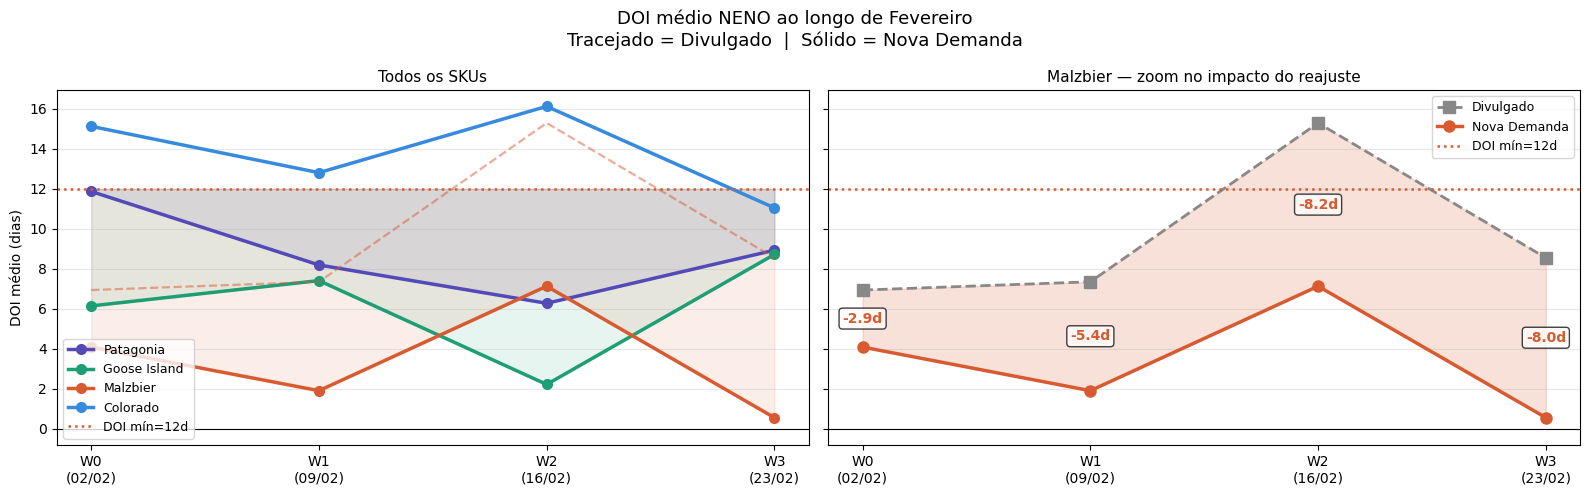

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.suptitle('DOI médio NENO ao longo de Fevereiro\n'
             'Tracejado = Divulgado  |  Sólido = Nova Demanda',
             fontsize=13)

# Painel esq — todos os SKUs
ax = axes[0]
ax.set_title('Todos os SKUs', fontsize=11)
for sku in SKUS:
    cor  = SKU_CORES[sku]
    vdiv = doi_div.loc[sku].values
    vnew = doi_new.loc[sku].values
    ax.plot(x4, vdiv, lw=1.6, ls='--', color=cor, alpha=0.50)
    ax.plot(x4, vnew, marker='o', lw=2.5, ms=7, color=cor, label=sku)
    ax.fill_between(x4, vnew, DOI_MIN,
                    where=(vnew < DOI_MIN), color=cor, alpha=0.10)
ax.axhline(DOI_MIN, color='#D85A30', lw=1.8, ls=':', label=f'DOI mín={DOI_MIN}d')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x4); ax.set_xticklabels(rotulos_w, fontsize=10)
ax.set_ylabel('DOI médio (dias)'); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Painel dir — zoom Malzbier com delta anotado
ax = axes[1]
cor  = SKU_CORES['Malzbier']
vdiv = doi_div.loc['Malzbier'].values
vnew = doi_new.loc['Malzbier'].values
ax.fill_between(x4, vdiv, vnew, alpha=0.18, color=cor)
ax.plot(x4, vdiv, marker='s', lw=2, ms=8, ls='--', color='#888', label='Divulgado')
ax.plot(x4, vnew, marker='o', lw=2.5, ms=8, color=cor, label='Nova Demanda')
for xi in range(4):
    mid = (vdiv[xi] + vnew[xi]) / 2
    ax.annotate(f'{vnew[xi]-vdiv[xi]:+.1f}d',
                xy=(xi, mid), ha='center', va='center', fontsize=10,
                color=cor, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.75))
ax.axhline(DOI_MIN, color='#D85A30', lw=1.8, ls=':', label=f'DOI mín={DOI_MIN}d')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Malzbier — zoom no impacto do reajuste', fontsize=11)
ax.set_xticks(x4); ax.set_xticklabels(rotulos_w, fontsize=10)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 3.3 Demanda total NENO — Divulgado vs Nova Demanda


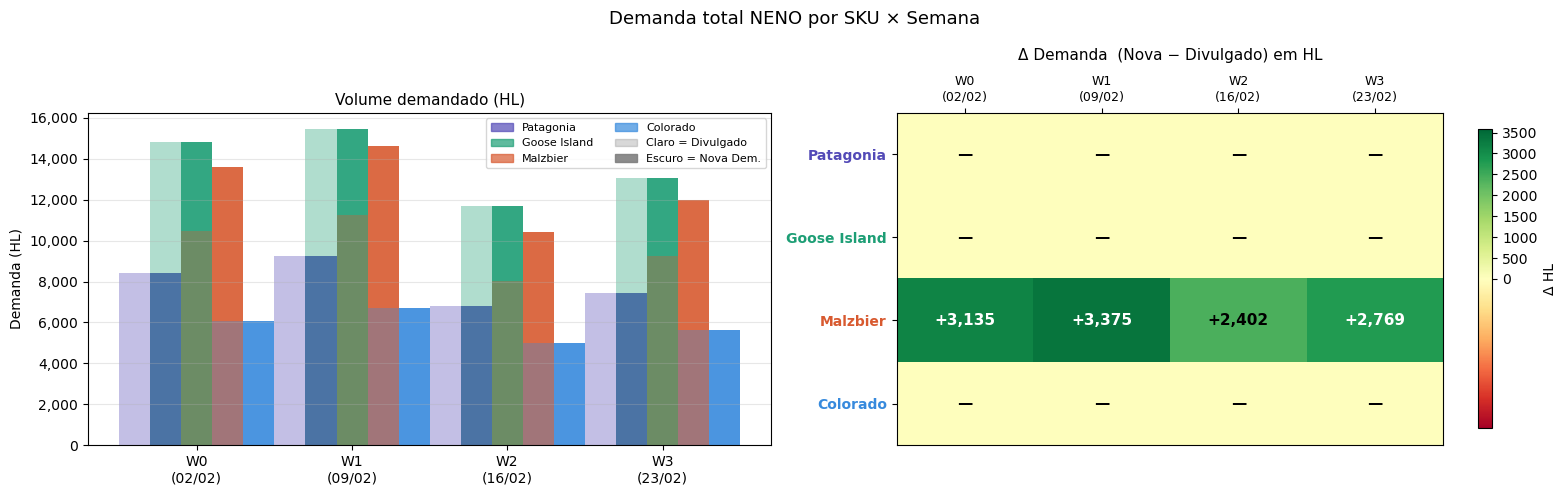

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Demanda total NENO por SKU × Semana', fontsize=13)

# Barras agrupadas
ax = axes[0]
ax.set_title('Volume demandado (HL)', fontsize=11)
w = 0.20
offsets = np.linspace(-(len(SKUS)-1)*w/2, (len(SKUS)-1)*w/2, len(SKUS))
for i, sku in enumerate(SKUS):
    cor = SKU_CORES[sku]
    ax.bar(x4 + offsets[i] - w/2, dem_div_w.loc[sku].values,
           width=w, color=cor, alpha=0.35, edgecolor='none')
    ax.bar(x4 + offsets[i] + w/2, dem_new_w.loc[sku].values,
           width=w, color=cor, alpha=0.90, edgecolor='none')
ax.set_xticks(x4); ax.set_xticklabels(rotulos_w, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax.set_ylabel('Demanda (HL)')
handles = [Patch(color=SKU_CORES[s], alpha=0.70, label=s) for s in SKUS]
handles += [
    Patch(color='gray', alpha=0.30, label='Claro = Divulgado'),
    Patch(color='gray', alpha=0.90, label='Escuro = Nova Dem.'),
]
ax.legend(handles=handles, fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)

# Heatmap delta demanda
ax = axes[1]
ax.set_title('Δ Demanda  (Nova − Divulgado) em HL', fontsize=11, pad=38)
vmax_d = delta_dem.values.max() + 200
norm_d = mcolors.TwoSlopeNorm(vmin=-200, vcenter=0, vmax=vmax_d)
im = ax.imshow(delta_dem.values, cmap=plt.cm.RdYlGn, norm=norm_d, aspect='auto')
for i, sku in enumerate(SKUS):
    for j in range(4):
        v = delta_dem.loc[sku, SEMANAS[j]]
        cor_t = 'white' if v > 2500 else 'black'
        lbl = f'+{v:,.0f}' if v > 0 else '—'
        ax.text(j, i, lbl, ha='center', va='center',
                fontsize=11, fontweight='bold', color=cor_t)
_style_ax(ax, SKUS, SKU_CORES)
plt.colorbar(im, ax=ax, label='Δ HL', shrink=0.90)

plt.tight_layout()
plt.show()
